# Tarea 1 
Pedro Dañobeytia Gomez

2022439131

Todos los análisis estadísticos se tomarán en cuenta usando 95% de confianza.

### 1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "stargazer"])
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

Cargué el .csv, verifique los tipos de variables y número de NaN por variable.

In [3]:
# Inspección inicial del dataset
data = pd.read_csv("../data/student_productivity.csv", decimal = '.')
print(f"Dimensiones del dataset: {data.shape[0]} filas × {data.shape[1]} columnas\n")

# Resumen de tipos y NaN
resumen = pd.DataFrame({
    'Tipo' : data.dtypes,
    'NaN'  : data.isna().sum(),
    '% NaN': (data.isna().mean() * 100).round(2)
}).sort_values('NaN', ascending=False)

print(resumen.to_string())


Dimensiones del dataset: 5621 filas × 22 columnas

                         Tipo   NaN  % NaN
drug_use              float64  4103  72.99
upcoming_deadline     float64   717  12.76
burnout_level         float64   716  12.74
exam_score            float64   709  12.61
part_time_job          object   703  12.51
online_classes_hours  float64   682  12.13
mental_health_score   float64   675  12.01
self_study_hours      float64   667  11.87
social_media_hours    float64   656  11.67
gaming_hours          float64   656  11.67
age                   float64   648  11.53
productivity_score    float64   638  11.35
focus_index           float64   633  11.26
academic_level         object   630  11.21
caffeine_intake_mg    float64   600  10.67
exercise_minutes       object   599  10.66
screen_time_hours     float64   586  10.43
study_hours           float64   574  10.21
gender                 object   558   9.93
sleep_hours           float64   553   9.84
internet_quality       object   523   9.30
stu

In [4]:
data.head(5)

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78


In [5]:
# Estadísticas descriptivas de las variables numéricas previas a cualquier modificación
data.describe().round(2)

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
count,5621.00,4973.00,5047.00,4954.00,4939.00,4965.00,4965.00,5068.00,5035.00,5021.00,4904.0,4946.00,1518.00,4988.00,4905.00,4983.00,4912.00
mean,2811.00,20.51,4.54,2.48,2.01,3.00,1.57,7.02,6.98,250.80,0.5,5.52,0.66,29.39,45.63,37.31,18.84
std,1622.79,2.88,1.82,1.18,0.98,1.47,1.11,1.16,2.48,143.69,0.5,2.87,0.47,10.00,14.26,16.84,12.12
min,1.00,16.00,0.00,0.00,0.00,0.00,0.00,4.00,1.00,0.00,0.0,1.00,0.00,1.00,1.00,1.00,1.00
25%,1406.00,18.00,3.26,1.66,1.32,2.00,0.68,6.25,5.28,129.00,0.0,3.00,0.00,22.46,35.77,25.33,9.41
50%,2811.00,20.00,4.53,2.48,2.01,2.99,1.50,7.02,6.95,251.00,1.0,5.00,1.00,29.38,45.65,36.92,17.99
75%,4216.00,23.00,5.76,3.28,2.69,4.03,2.35,7.82,8.70,375.00,1.0,8.00,1.00,36.23,55.41,49.20,27.41
max,5621.00,25.00,11.84,7.41,6.00,8.28,5.64,10.00,15.30,499.00,1.0,10.00,1.00,63.48,97.58,98.02,64.09


<Axes: >

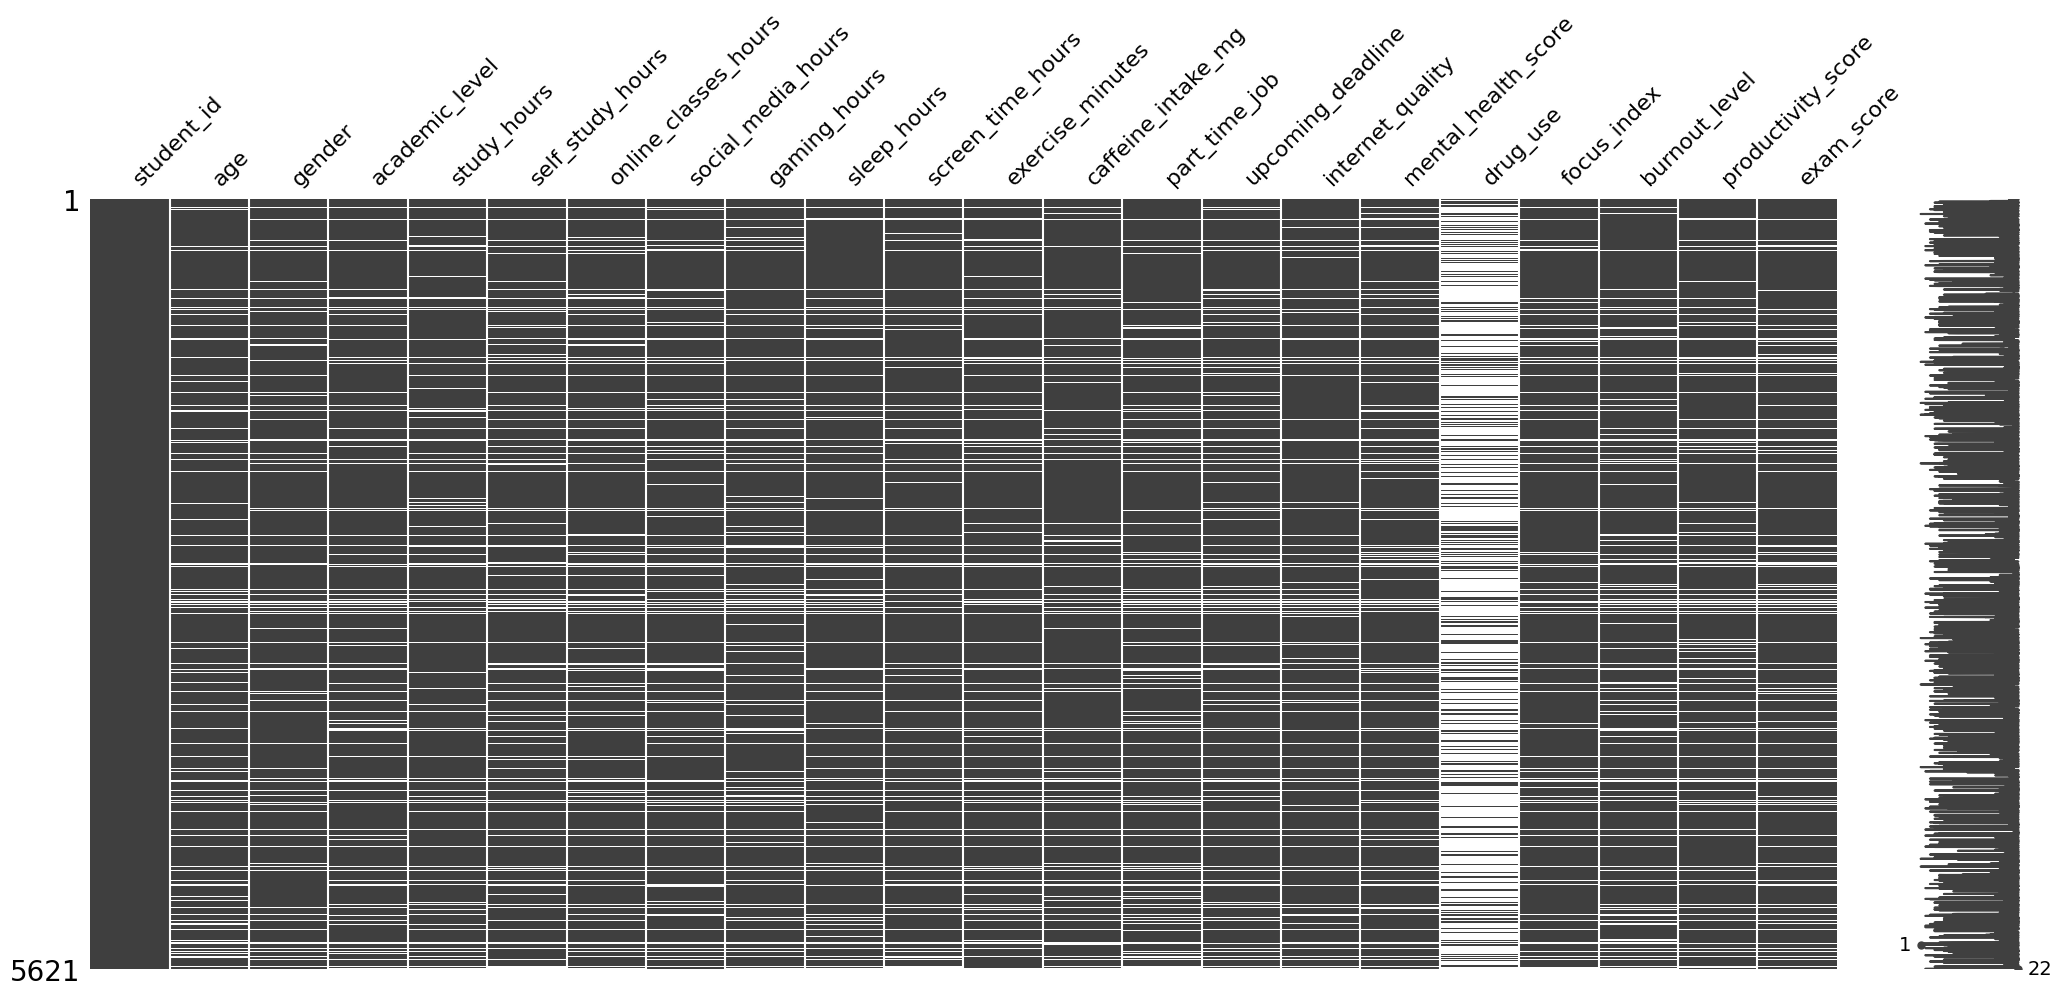

In [6]:
# Se muestran la distribución de valores NaN
msno.matrix(data)

### Distribuciones previo a la limpieza.

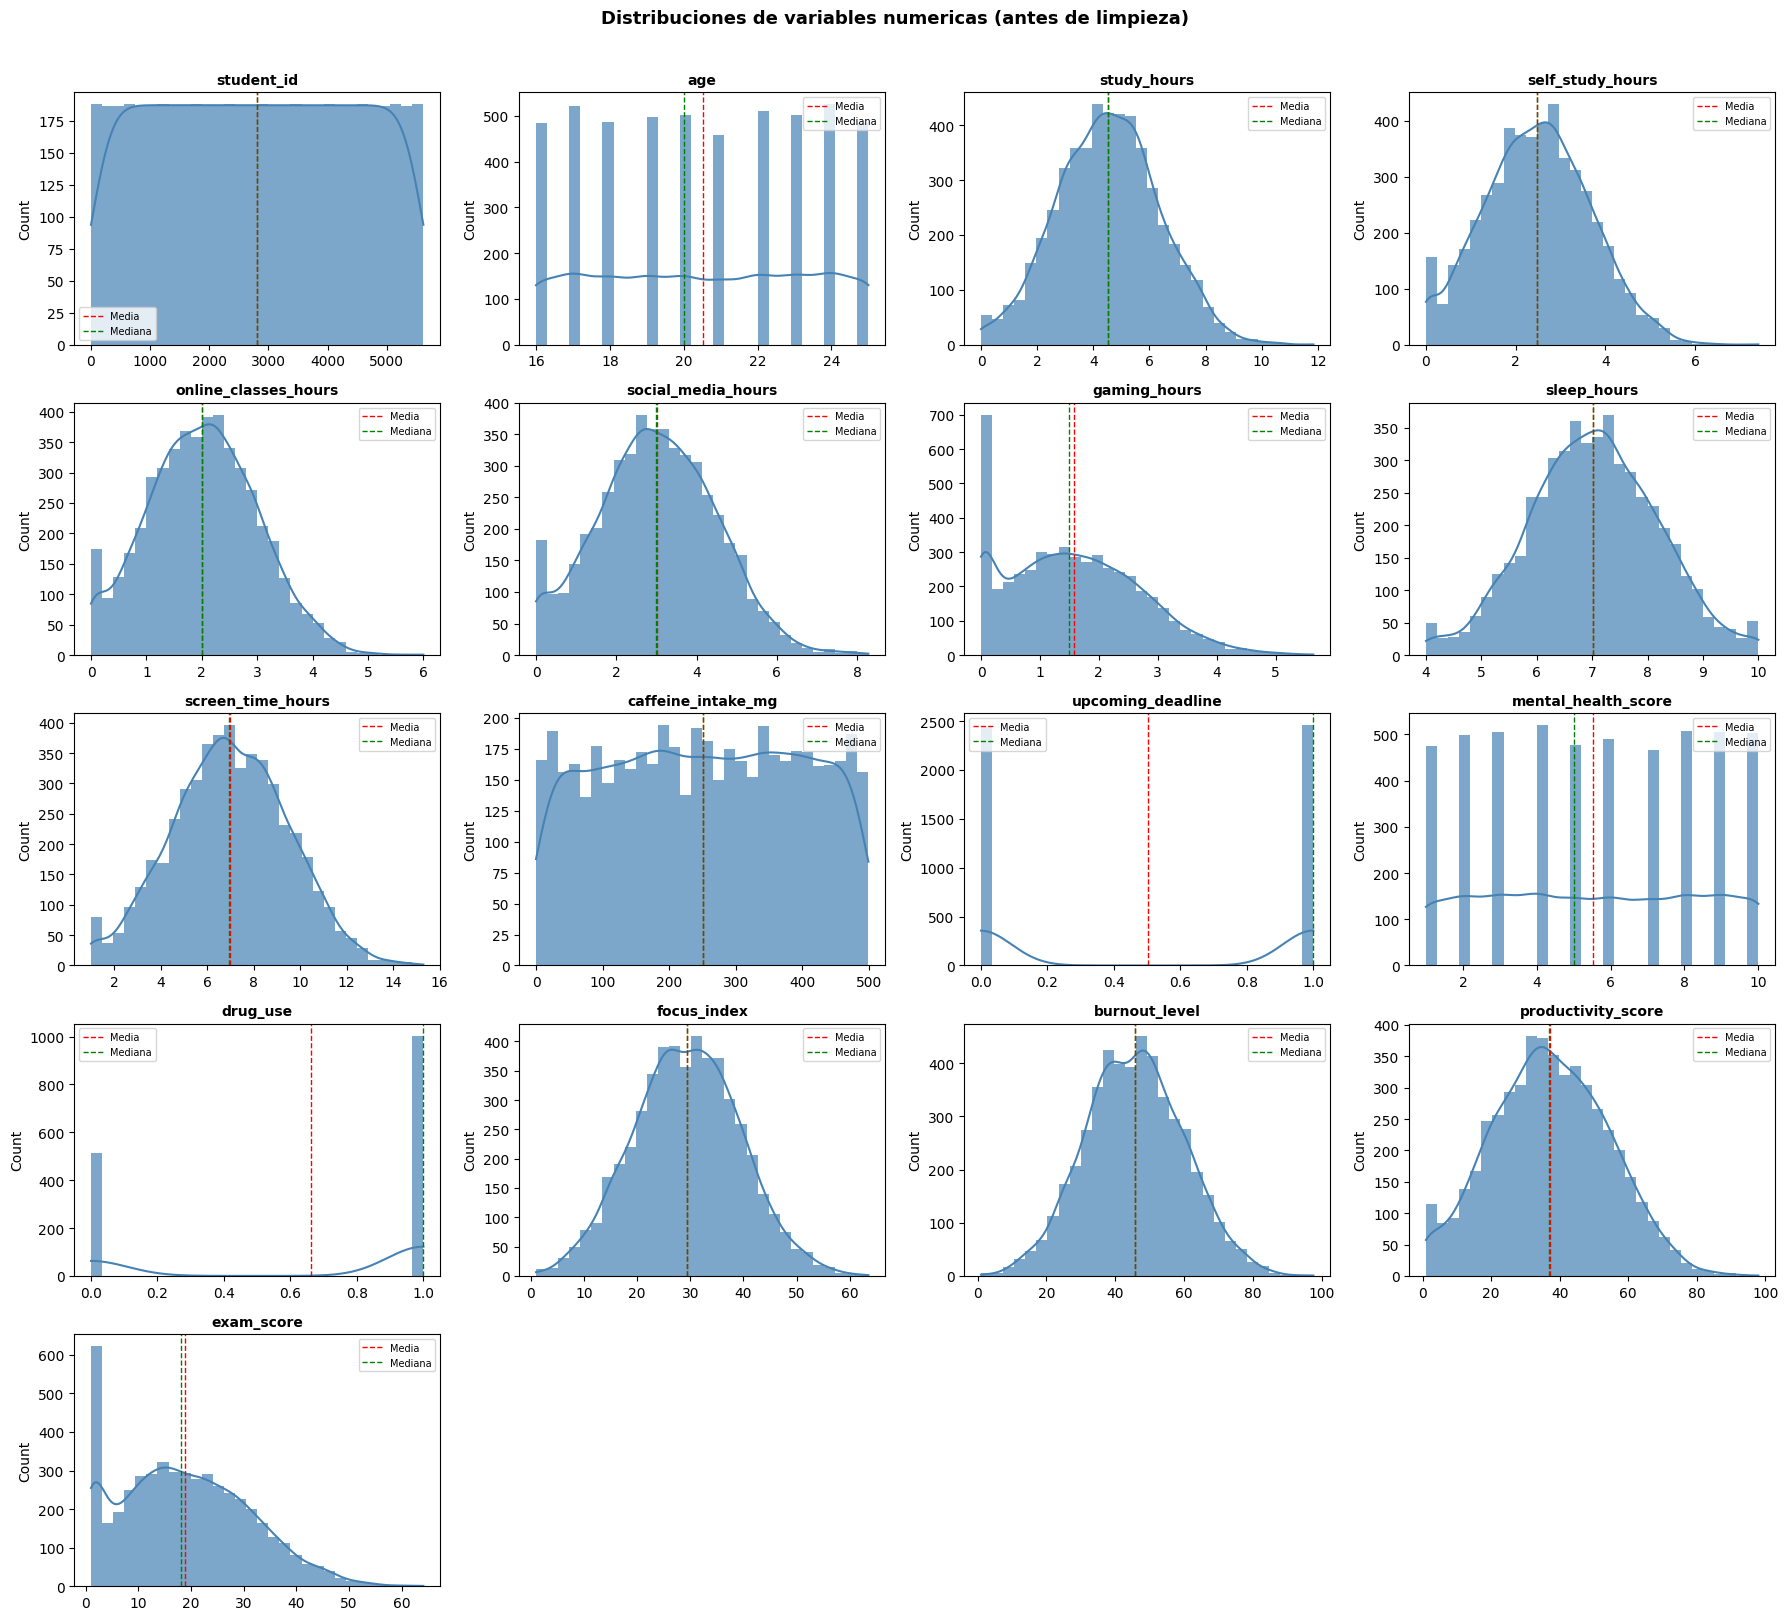

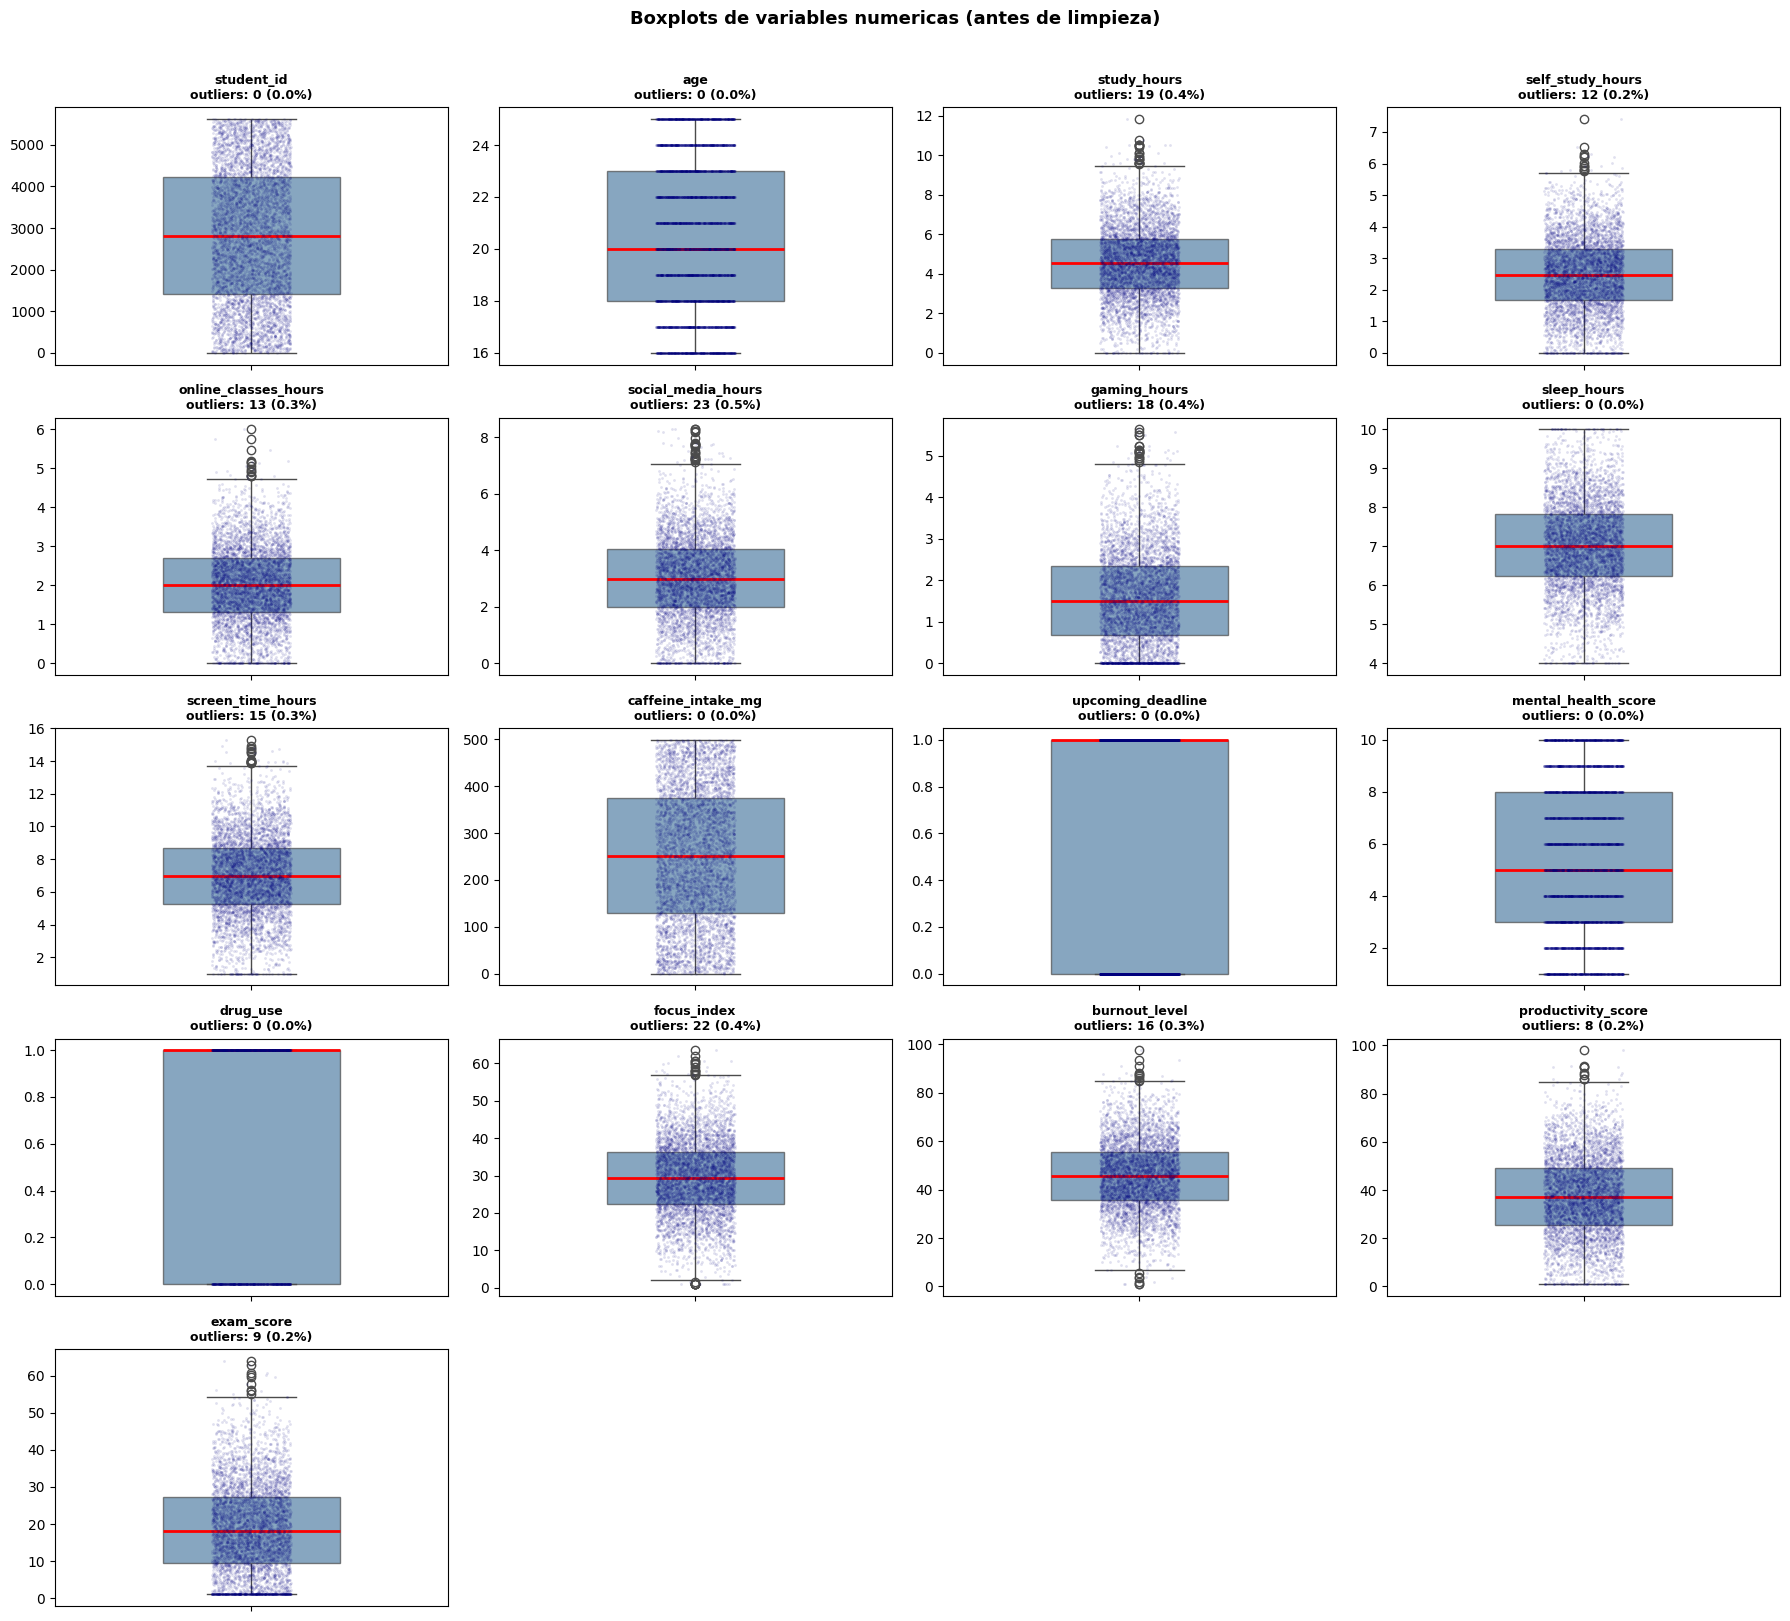

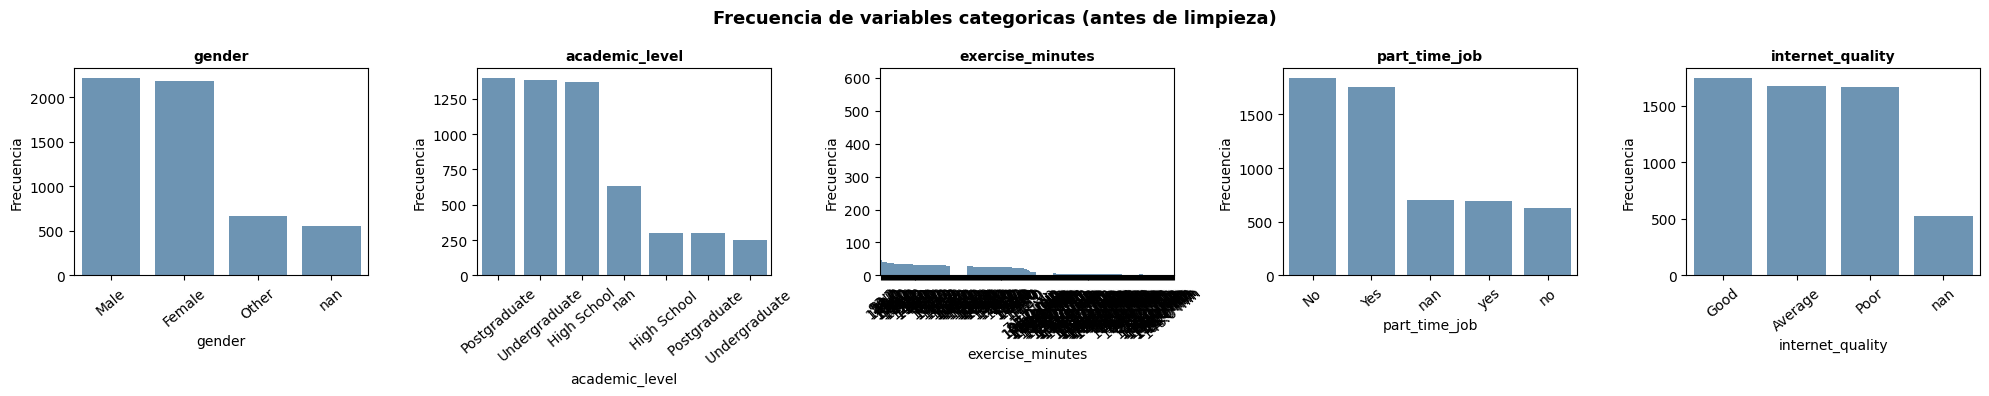

In [7]:
# Variables numericas y categoricas (antes de limpieza)
num_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = data.select_dtypes(include=['object']).columns.tolist()

n_cols = 4
n_rows = -(-len(num_cols) // n_cols)  

# Histogramas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data[col].dropna(), bins=30, kde=True, ax=axes[i],
                 color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].axvline(data[col].mean(),   color='red',   linestyle='--', linewidth=1, label='Media')
    axes[i].axvline(data[col].median(), color='green', linestyle='--', linewidth=1, label='Mediana')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de variables numericas (antes de limpieza)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Boxplots (outliers) 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    Q1, Q3 = data[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)).sum()
    pct_out = n_out / data[col].notna().sum() * 100

    sns.boxplot(y=data[col].dropna(), ax=axes[i],
                color='steelblue', width=0.45,
                boxprops=dict(alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
    sns.stripplot(y=data[col].dropna(), ax=axes[i],
                  color='navy', size=2, jitter=True, alpha=0.12)
    axes[i].set_title(f'{col}\noutliers: {n_out} ({pct_out:.1f}%)',
                      fontsize=9, fontweight='bold')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de variables numericas (antes de limpieza)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Frecuencias de categoricas 
fig, axes = plt.subplots(1, len(cat_cols), figsize=(4 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    counts = data[col].value_counts(dropna=False)
    sns.barplot(x=counts.index.astype(str), y=counts.values,
                ax=axes[i], color='steelblue', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=40)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Frecuencia de variables categoricas (antes de limpieza)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Histogramas y distribuciones:** Variables como `age`, `study_hours`, `sleep_hours`, `screen_time_hours` tienen distribuciones aproximadamente simétricas contandocon medias y medianas muy cercana.
Otras como `social_media_hours`, `caffeine_intake_mg` y `gaming_hours` muestran cierto sesgo hacia la derecha con colas largas.
`exam_score` presenta una distribución bimodal.

**Boxplots:** Se han detectado outliers en varias variables, más especificamente en `caffeine_intake_mg` y `social_media_hours`.
Las variables binarias `upcoming_deadline` y `part_time_job` presentan distribuciones practicamente uniformes.

**Categóricas:** Se muestran inconsistencias en `part_time_job`, categorías innecesarias en `academic_level`, y en `exercise_minutes` se presenta un caos debido a la existencia del sufijo min en la columna.

### Limpieza de datos

A partir de la inspección anterior se toman las siguientes decisiones:

| Variable | Problema detectado | Tratamiento |
|---|---|---|
| `drug_use` | 73% NaN | **Se elimina la columna** |
| `exercise_minutes` | Variable tipo string | Convertir a variable numérica → imputar mediana |
| `exam_score`,`upcoming_deadline`, `part_time_job` | ~12‑13% NaN | Eliminar filas (Variable dependiente / Distribución casi uniforme) |
| Variables numéricas continuas restantes | <12% NaN | Imputar con mediana (distribuciónes asimétricas) |
| `gender`, `internet_quality` | Categórica con NaN | Imputar con moda |
| `academic_level` | Espacios extra + NaN | Strip + imputar moda |
| `part_time_job` | Mezcla 'yes'/'Yes'/'no'/'No' | Categorizar la variable

In [ ]:
data['aux'] = data['exam_score'].notna().astype(int)

data['dio_examen'] = np.nan

data.loc[(data['aux'] == 1) & (data['exam_score'] > 1.0), 'dio_examen'] = 1
data.loc[(data['aux'] == 1) & (data['exam_score'] == 1.0), 'dio_examen'] = 0

print("\nConteo de NaN originales en exam_score:", data['exam_score'].isna().sum())
print("Conteo de NaN finales en dio_examen:", data['dio_examen'].isna().sum())

Se crea la variable binaria `aux` la cual sirve para ver si la variable `exam_score` tiene dato, y a raiz de ello se crea la variable `dio_exam`, la cual cruza estas 2 variables viendo que se respete la integridad de la data.

Filas finales: 4548  |  NaN restantes: 0


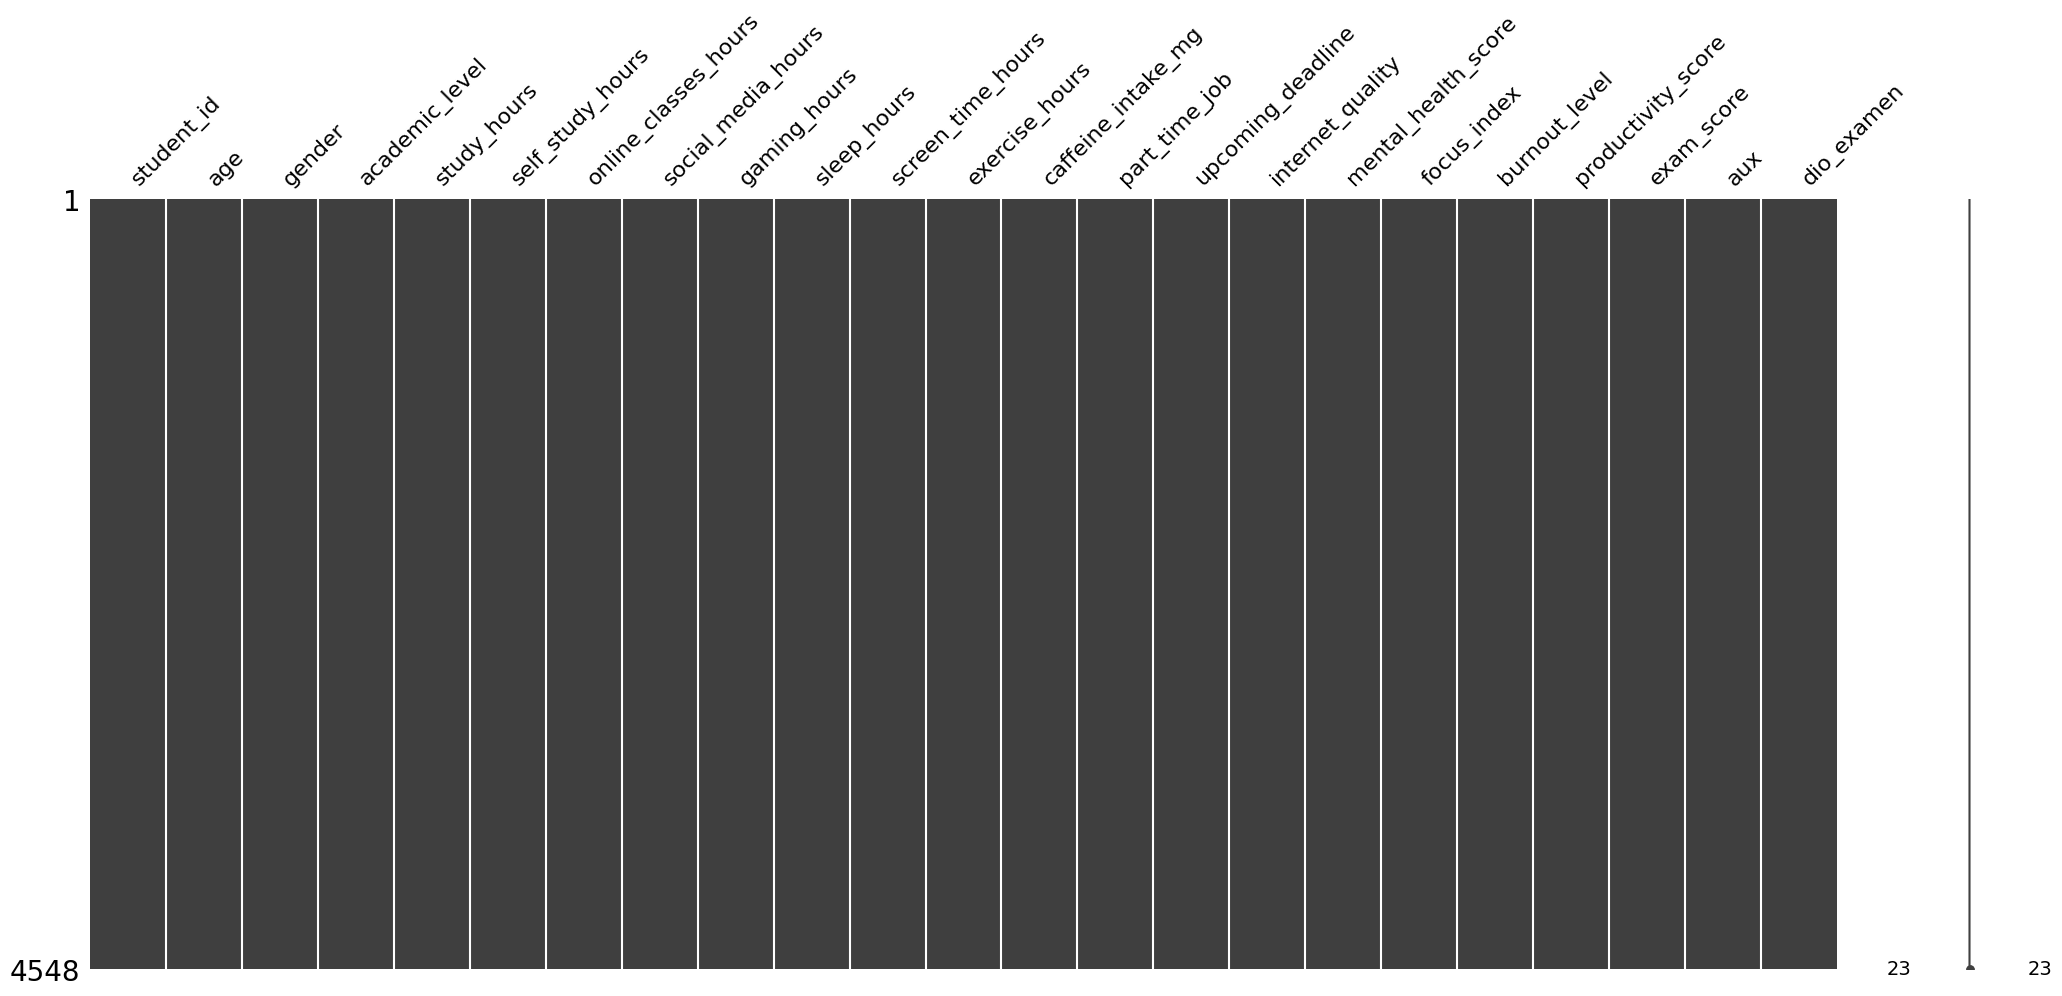

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,aux,dio_examen
0,1,20,1,1,5.37,2.09,1.85,3.66,2.32,7.73,...,0,0,2,3.0,19.01,31.77,42.59,25.08,1,1.0
1,2,16,0,0,5.85,5.04,1.87,3.60,2.79,6.11,...,0,0,2,10.0,42.10,45.89,67.15,37.83,1,1.0
2,3,18,0,1,5.69,2.27,0.00,2.93,3.94,7.11,...,0,0,1,5.0,21.93,37.07,37.68,18.66,1,1.0
3,4,24,1,1,2.32,1.06,2.30,4.34,2.37,8.54,...,0,1,0,3.0,13.47,43.63,12.83,1.00,1,0.0
4,5,24,0,2,3.87,2.63,2.54,3.71,1.30,7.69,...,0,1,0,2.0,19.95,56.62,18.53,7.78,1,1.0


In [9]:
# Se elimina la columna drug_use 
data.drop(columns=['drug_use'], inplace=True)

# Corregir exercise_minutes y pasarlo a horas 
# Viene como string, se conertirá a horas numéricas
data['exercise_minutes'] = pd.to_numeric(data['exercise_minutes'], errors='coerce')
data['exercise_minutes'] = (data['exercise_minutes'] / 60).round(2)
data.rename(columns={'exercise_minutes': 'exercise_hours'}, inplace=True)

# Se eliminan los espacios en blanco en la variable academic_level
data['academic_level'] = data['academic_level'].str.strip()

# Se eliminan las filas sin variable dependiente
# No se imputa exam_score: asignar un valor introduciría sesgo en el modelo
data.dropna(subset=['exam_score'], inplace=True)

# Eliminar filas sin upcoming_deadline y part_time_job 
# Distribución casi uniforme → imputar sería equivalente a aleatorio
data.dropna(subset=['upcoming_deadline', 'part_time_job'], inplace=True)

# Se imputan variables numéricas 
# Media: distribución aproximadamente simétrica
for col in ['age', 'study_hours', 'self_study_hours', 'online_classes_hours',
                  'sleep_hours', 'screen_time_hours', 'focus_index', 'burnout_level']:
    data[col] = data[col].fillna(round(data[col].mean(), 2))

# Mediana: distribución asimétrica o con outliers
for col in ['social_media_hours', 'caffeine_intake_mg', 'mental_health_score',
                    'productivity_score', 'exercise_hours', 'gaming_hours']:
    data[col] = data[col].fillna(round(data[col].median(), 2))

# Imputar las categóricas con moda 
for col in ['gender', 'internet_quality', 'academic_level']:
    data[col] = data[col].fillna(data[col].mode()[0])

# Algunos ajustes de formato 
data['age'] = data['age'].apply(np.trunc).astype(int)
data['upcoming_deadline'] = data['upcoming_deadline'].apply(np.trunc).astype(int)

#  Encoding de las variables categóricas 
data['gender']          = data['gender'].replace({'Female': 0, 'Male': 1, 'Other': 2})
data['academic_level']  = data['academic_level'].replace({'High School': 0, 'Undergraduate': 1, 'Postgraduate': 2})
data['part_time_job']   = data['part_time_job'].replace({'No': 0, 'no': 0, 'Yes': 1, 'yes': 1})
data['internet_quality'] = data['internet_quality'].replace({'Poor': 0, 'Average': 1, 'Good': 2})

# Verificación
nans_restantes = data.isna().sum().sum()
print(f"Filas finales: {len(data)}  |  NaN restantes: {nans_restantes}")
msno.matrix(data)
plt.show()

data.head(5)

In [10]:
# Estadísticas descriptivas post-limpieza 
data.describe().round(2)


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,aux,dio_examen
count,4548.00,4548.00,4548.00,4548.00,4548.00,4548.00,4548.00,4548.00,4548.00,4548.00,...,4548.0,4548.0,4548.00,4548.00,4548.00,4548.00,4548.00,4548.00,4548.0,4548.00
mean,2803.21,20.51,0.70,1.02,4.53,2.47,2.02,3.00,1.57,7.02,...,0.5,0.5,1.04,5.51,29.41,45.66,37.30,18.83,1.0,0.91
std,1622.02,2.83,0.68,0.82,1.81,1.17,0.98,1.46,1.10,1.15,...,0.5,0.5,0.82,2.85,9.86,14.08,16.76,12.14,0.0,0.29
min,1.00,16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,...,0.0,0.0,0.00,1.00,1.00,1.00,1.00,1.00,1.0,0.00
25%,1399.75,18.00,0.00,0.00,3.27,1.66,1.34,2.02,0.70,6.26,...,0.0,0.0,0.00,3.00,22.66,36.01,25.44,9.33,1.0,1.00
50%,2793.50,20.00,1.00,1.00,4.53,2.47,2.02,2.98,1.50,7.02,...,0.5,1.0,1.00,5.00,29.41,45.66,36.88,17.99,1.0,1.00
75%,4216.25,23.00,1.00,2.00,5.74,3.27,2.66,4.02,2.34,7.80,...,1.0,1.0,2.00,8.00,36.07,54.98,48.97,27.45,1.0,1.00
max,5621.00,25.00,2.00,2.00,11.84,7.41,6.00,8.21,5.64,10.00,...,1.0,1.0,2.00,10.00,63.48,97.58,98.02,64.09,1.0,1.00


En la limpieza se perdieron 1073 filas, conservando un 80.9% de las observaciones iniciales del dataset (4548 de 5626) a continuación se muestran las estadísticas descritptivas de las variables elegidas después de la imputación.

In [11]:
# Se crean variables binarias de variables continuas condicionales que despertaron cierto interés.
data['exercise'] = np.where(data['exercise_hours'] > 0, 1, 0)
data['gaming'] = np.where(data['gaming_hours'] > 0, 1, 0)
data["social"] = np.where(data["social_media_hours"]> 0, 1, 0)

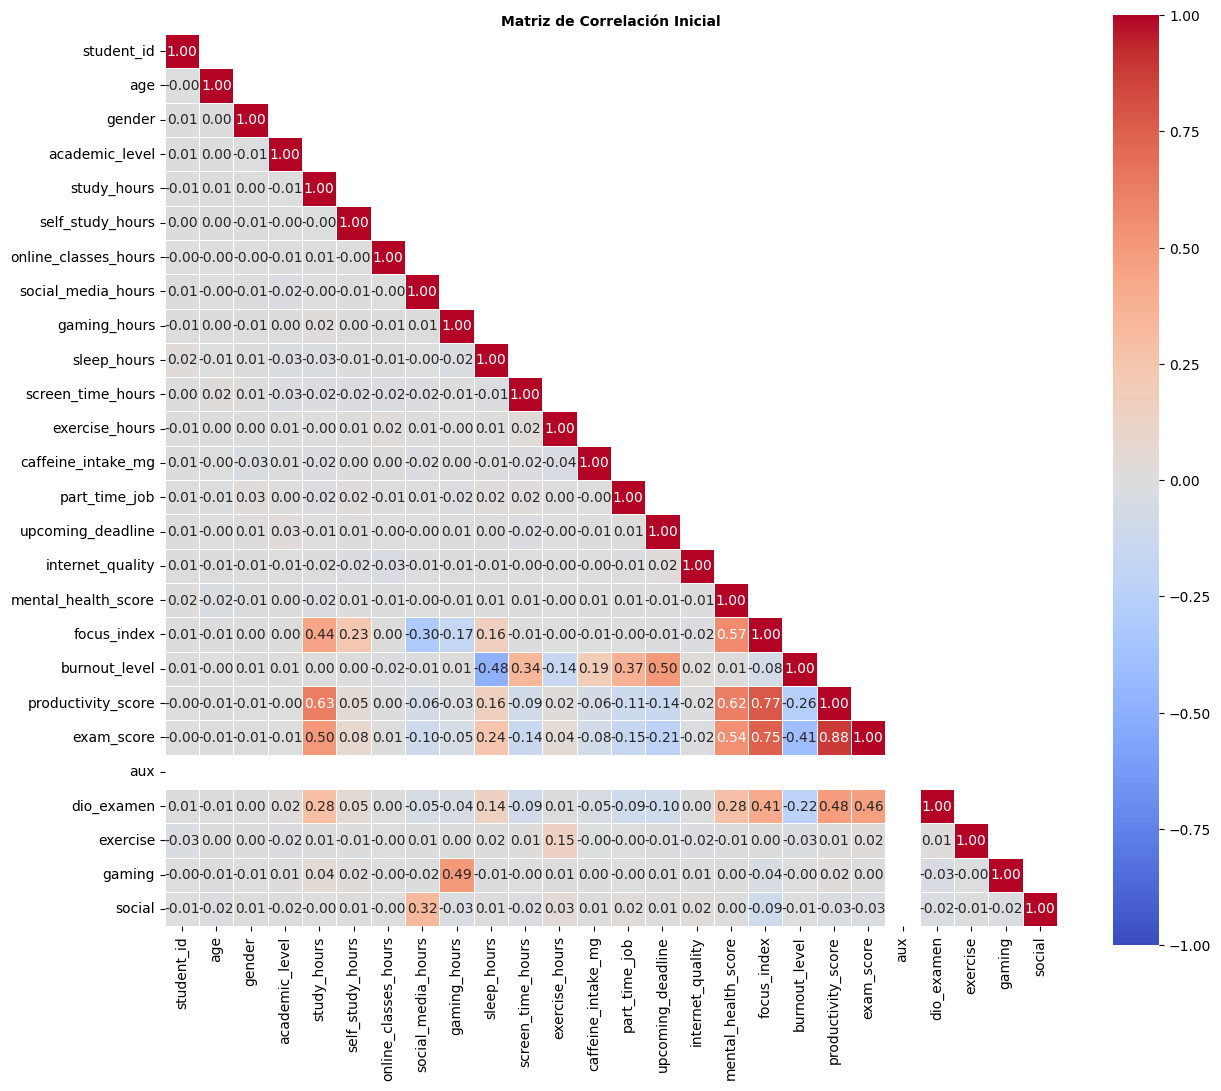

In [12]:
corr_matrix = data.corr()
mask_tri = np.triu(np.ones_like(corr_matrix, dtype=bool), k = 1)

fig, ax = plt.subplots(figsize = (13, 11))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm',
            center = 0, vmin = -1, vmax = 1,
            square = True, linewidths = 0.5,
            mask = mask_tri, ax = ax)
ax.set_title('Matriz de Correlación Inicial', fontsize = 10, fontweight = 'bold')
plt.tight_layout()
plt.show()


In [13]:
correlaciones_examen = data.corr()['dio_examen'].sort_values(ascending = False)

print("Correlación con la probabilidad de rendir (dio_examen)")
print(correlaciones_examen)

Correlación con la probabilidad de rendir (dio_examen)
dio_examen              1.000000
productivity_score      0.480513
exam_score              0.460979
focus_index             0.410650
study_hours             0.283844
mental_health_score     0.281160
sleep_hours             0.136456
self_study_hours        0.049245
academic_level          0.016687
exercise                0.013518
exercise_hours          0.011251
student_id              0.007339
internet_quality        0.001863
gender                  0.001442
online_classes_hours    0.001377
age                    -0.012429
social                 -0.024381
gaming                 -0.034446
gaming_hours           -0.040479
caffeine_intake_mg     -0.045455
social_media_hours     -0.050596
screen_time_hours      -0.087162
part_time_job          -0.093871
upcoming_deadline      -0.099634
burnout_level          -0.224066
aux                          NaN
Name: dio_examen, dtype: float64


La matriz de correlación junto a la lista consiguiente revelan 4 relaciones relevantes con la variable `dio_examen`: `productivity_score` (+0.48), `focus_index` (+0.41), `mental_health_score` (+0.28)
y `study_hours` (+0.28) quienes correlacionan positivamente, mientras que `burnout_level` (-0.22) es la que tiene más efecto negativo. Las binarias tienen menos efecto del esperado.

Alta correlación entre `productivity_score` y `focus_index` (0.77) y entre `productivity_score` y `exam_score` (0.88). 

De este listado elegí las variables que podrían servir para describir el comportamiento de la variable dio_examen.

In [14]:
var_imp_continuas = ['study_hours', 'exercise_hours', 'age', 'burnout_level', 
                       'sleep_hours', 'productivity_score', 'focus_index', 'screen_time_hours', 'exam_score']

var_imp_categoricas = ['upcoming_deadline', 'part_time_job', 'mental_health_score', 
                       'academic_level', 'exercise', 'gaming', 'social']



### Graficos de variables seleccionadas después de la limpieza

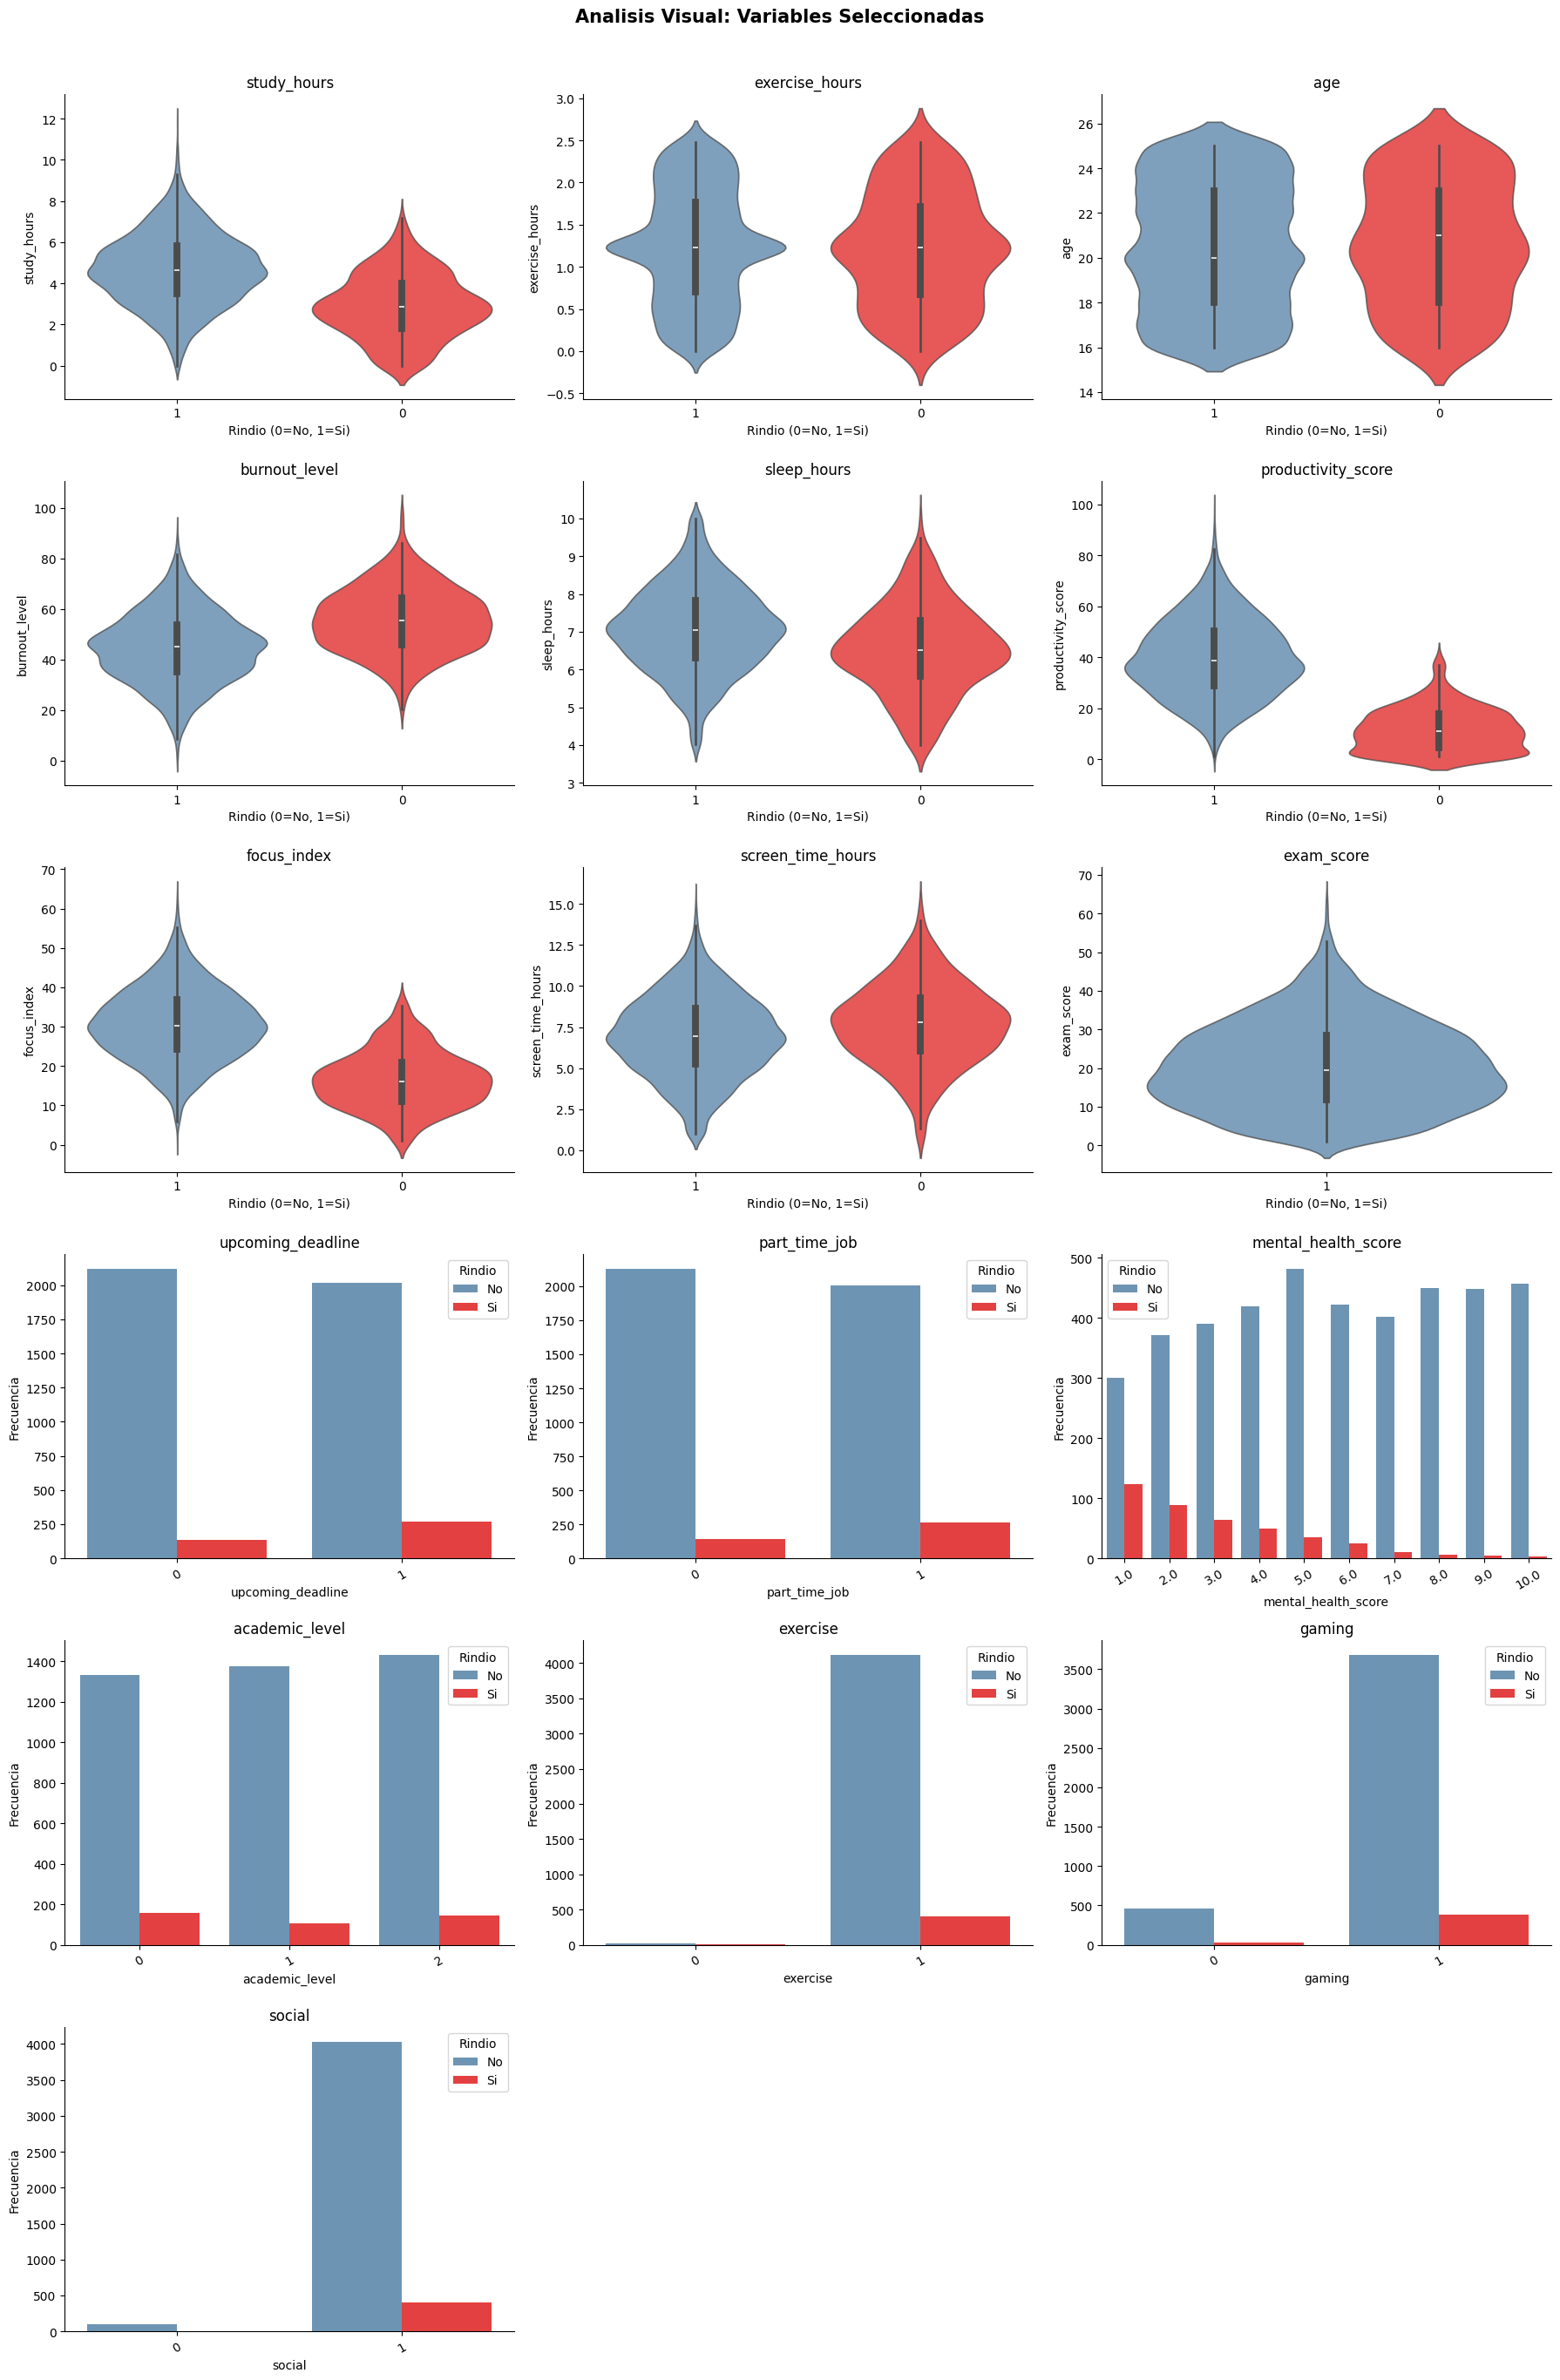

In [15]:
# Preparar subset con dio_examen valido
mask = data['dio_examen'].notna()
temp = data[mask].copy()
temp['dio_examen'] = temp['dio_examen'].astype(int).astype(str)

n_cols  = 3
n_total = len(var_imp_continuas) + len(var_imp_categoricas)
n_rows  = -(-n_total // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()
fig.suptitle('Analisis Visual: Variables Seleccionadas',
             fontsize=15, fontweight='bold', y=1.01)

# Continuas: violin por dio_examen 
for i, var in enumerate(var_imp_continuas):
    temp_var = temp[temp['exam_score'] > 1] if var == 'exam_score' else temp
    sns.violinplot(
        data=temp_var, x='dio_examen', y=var, ax=axes[i],
        palette={'0': 'red', '1': 'steelblue'},
        alpha=0.75, inner='box'
    )
    axes[i].set(title=f'{var}', xlabel='Rindio (0=No, 1=Si)', ylabel=var)

# Categoricas: countplot por examen 
for j, var in enumerate(var_imp_categoricas):
    idx = len(var_imp_continuas) + j
    sns.countplot(
        data=temp, x=var, hue='dio_examen', ax=axes[idx],
        palette={'0': 'red', '1': 'steelblue'}, alpha=0.85
    )
    axes[idx].set(title=f'{var}', xlabel=var, ylabel='Frecuencia')
    axes[idx].tick_params(axis='x', rotation=30)
    axes[idx].legend(title='Rindio', labels=['No', 'Si'])

# Apagar ejes sobrantes
for k in range(n_total, len(axes)):
    axes[k].set_visible(False)

sns.despine()
plt.tight_layout()
plt.show()


Se permite la visualización entre quienes  
rindieron el examen (`dio_examen` = 1) y quienes no lo hicieron (`dio_examen` = 0).

**`productivity_score` y `focus_index`:** Las variables están claramente separadas entre grupos, los que dieron el examen presentan valores notoriamente altos.

**`burnout_level`:** Quienes no rindieron tienen una distribución más alta, aunque esperaba un efecto más marcado, el agotamiento desincentiva el rendir el examen.

**`study_hours` y `sleep_hours`:** Ambas tienen diferencias más sutiles, nuevamente esperaba lo contario, quienes no rindieron el examen muestran medias superiores.

**`exam_score`:** Dado que quienes no rindieron tienen un puntaje de 1 se decidio segmentar por solo los que lo dieron, se nota una amplia distribución con alta variabilidad.

**`upcoming_deadline` y `part_time_job` (categóricas):** No muestran diferencias marcadas 
entre grupos.

**Binarias armadas:** Dado lo mostrado en el gráfico se llegó a que solo 29 muestras NO hacen ejercicio, por la poca variabilidad se descartará de los análisis, dentro de las otras 2 muestran que la mayoría de los estudiantes juega y usa redes (lo ques es esperable).

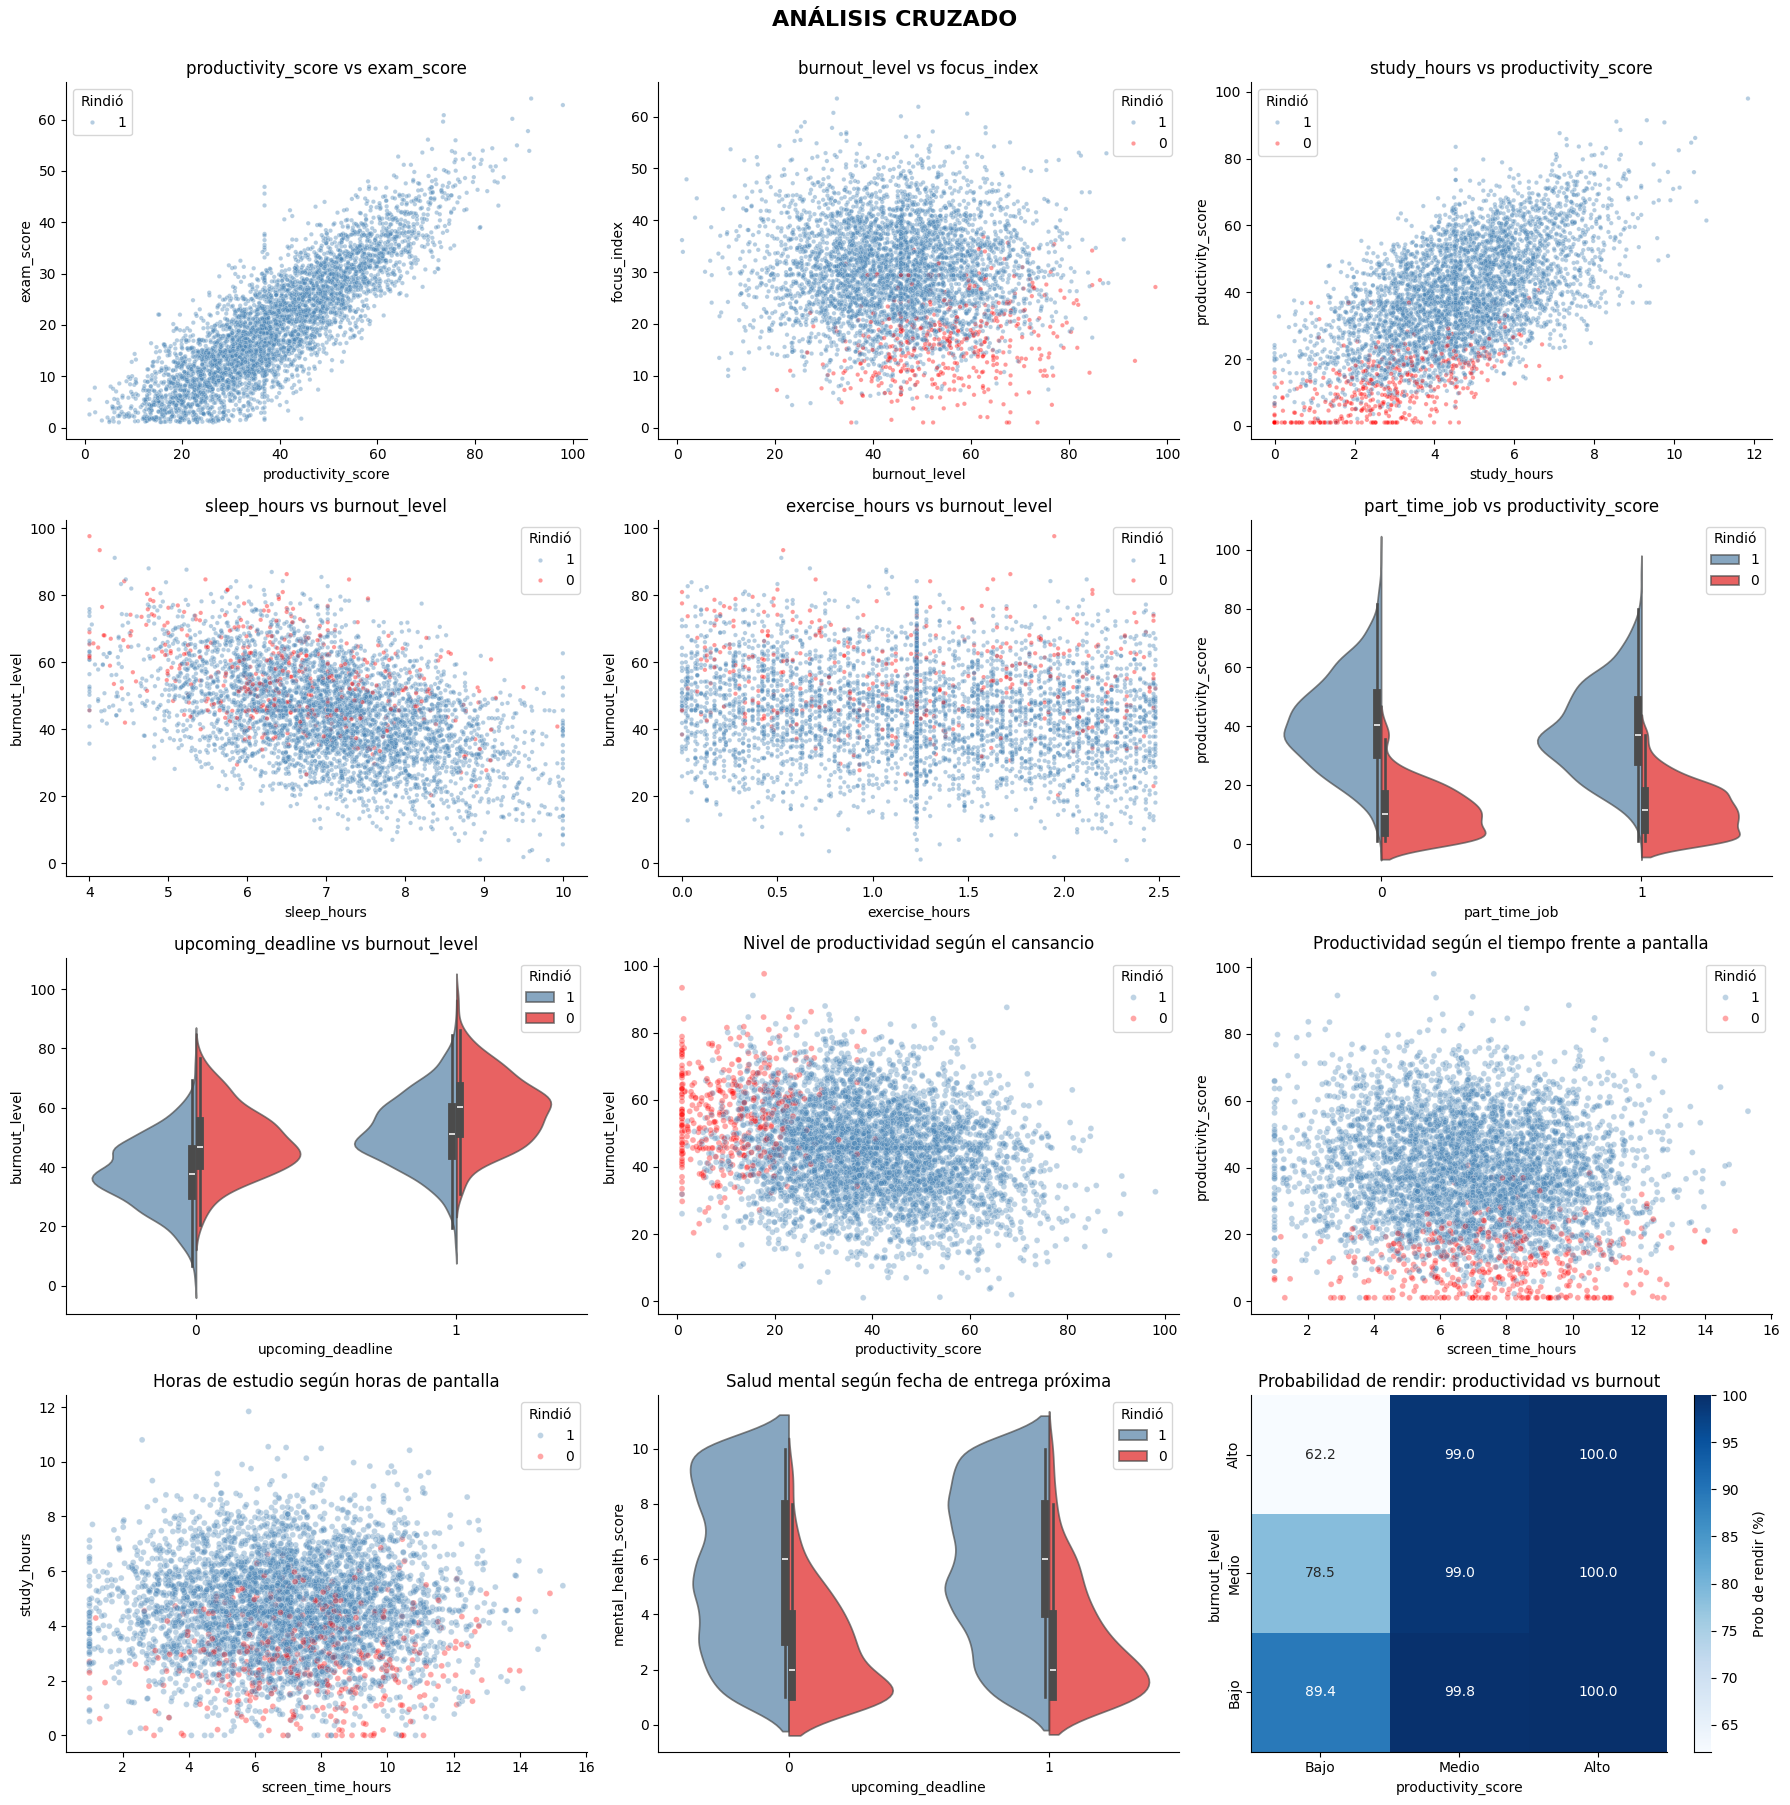

In [16]:
mask = data['dio_examen'].notna()
temp = data[mask].copy()
temp['dio_examen'] = temp['dio_examen'].astype(int).astype(str)

fig, axes = plt.subplots(4, 3, figsize=(18, 18))
fig.suptitle('ANÁLISIS CRUZADO', fontsize = 16, fontweight = 'bold', y = 1)
fig.tight_layout(rect = [0, 0, 1, 0.96])

# productivity_score vs exam_score
sns.scatterplot(data = temp[temp['exam_score'] > 1], x = 'productivity_score', y = 'exam_score',
                hue = 'dio_examen', palette = {'0': 'red', '1': 'steelblue'},
                alpha = 0.4, s = 10, ax = axes[0, 0])
axes[0, 0].set(title = 'productivity_score vs exam_score', xlabel = 'productivity_score', ylabel = 'exam_score')
axes[0, 0].legend(title = 'Rindió')

# burnout_level vs focus_index 
sns.scatterplot(data = temp, x = 'burnout_level', y = 'focus_index',
                hue = 'dio_examen', palette = {'0': 'red', '1': 'steelblue'},
                alpha = 0.4, s = 10, ax = axes[0, 1])
axes[0, 1].set(title = 'burnout_level vs focus_index', xlabel = 'burnout_level', ylabel = 'focus_index')
axes[0, 1].legend(title = 'Rindió')

# study_hours vs productivity_score
sns.scatterplot(data = temp, x = 'study_hours', y = 'productivity_score',
                hue = 'dio_examen', palette = {'0': 'red', '1': 'steelblue'},
                alpha = 0.4, s = 10, ax = axes[0, 2])
axes[0, 2].set(title = 'study_hours vs productivity_score', xlabel = 'study_hours', ylabel = 'productivity_score')
axes[0, 2].legend(title = 'Rindió')

# sleep_hours vs burnout_level
sns.scatterplot(data = temp, x = 'sleep_hours', y = 'burnout_level',
                hue = 'dio_examen', palette = {'0': 'red', '1': 'steelblue'},
                alpha = 0.4, s = 10, ax = axes[1, 0])
axes[1, 0].set(title = 'sleep_hours vs burnout_level', xlabel = 'sleep_hours', ylabel = 'burnout_level')
axes[1, 0].legend(title = 'Rindió')

# exercise_hours vs burnout_level
sns.scatterplot(data = temp, x = 'exercise_hours', y = 'burnout_level',
                hue = 'dio_examen', palette = {'0': 'red', '1': 'steelblue'},
                alpha = 0.4, s = 10, ax = axes[1, 1])
axes[1, 1].set(title = 'exercise_hours vs burnout_level', xlabel = 'exercise_hours', ylabel = 'burnout_level')
axes[1, 1].legend(title = 'Rindió')

# part_time_job vs productivity_score
sns.violinplot(data = temp, x = 'part_time_job', y = 'productivity_score', hue = 'dio_examen',
               palette = {'0': 'red', '1': 'steelblue'}, alpha = 0.7, inner = 'box',
               ax = axes[1, 2], split = True)
axes[1, 2].set(title ='part_time_job vs productivity_score', xlabel = 'part_time_job', ylabel = 'productivity_score')
axes[1, 2].legend(title = 'Rindió')

# upcoming_deadline vs burnout_level
sns.violinplot(data = temp, x = 'upcoming_deadline', y = 'burnout_level', hue = 'dio_examen',
               palette = {'0': 'red', '1': 'steelblue'}, alpha = 0.7, inner = 'box',
               ax = axes[2, 0], split = True)
axes[2, 0].set(title = 'upcoming_deadline vs burnout_level', xlabel = 'upcoming_deadline', ylabel = 'burnout_level')
axes[2, 0].legend(title = 'Rindió')

# Nivel de productividad según el cansancio - Scatterplot
sns.scatterplot(data = temp, x = 'productivity_score', y = 'burnout_level', hue = 'dio_examen',
                palette = {'0': 'red', '1': 'steelblue'}, alpha = 0.35, s = 18, ax = axes[2, 1])
axes[2, 1].set(title = 'Nivel de productividad según el cansancio', xlabel = 'productivity_score', ylabel = 'burnout_level')
axes[2, 1].legend(title = 'Rindió')

# Productividad según el tiempo frente a pantalla - Scatterplot
sns.scatterplot(data = temp, x = 'screen_time_hours', y = 'productivity_score', hue = 'dio_examen',
                palette = {'0': 'red', '1': 'steelblue'}, alpha = 0.35, s = 18, ax = axes[2, 2])
axes[2, 2].set(title = 'Productividad según el tiempo frente a pantalla', xlabel = 'screen_time_hours', ylabel = 'productivity_score')
axes[2, 2].legend(title = 'Rindió')

# Horas de estudio según horas de pantalla - Scatterplot
sns.scatterplot(data = temp, x = 'screen_time_hours', y = 'study_hours', hue = 'dio_examen',
                palette = {'0': 'red', '1': 'steelblue'}, alpha = 0.35, s = 18, ax = axes[3, 0])
axes[3, 0].set(title = 'Horas de estudio según horas de pantalla', xlabel = 'screen_time_hours', ylabel = 'study_hours')
axes[3, 0].legend(title = 'Rindió')


sns.violinplot(data = temp, x = 'upcoming_deadline', y = 'mental_health_score', hue = 'dio_examen', split = True,
                inner = 'box', palette = {'0': 'red', '1': 'steelblue'}, alpha = 0.7, ax = axes[3, 1])
axes[3, 1].set(title = 'Salud mental según fecha de entrega próxima', xlabel = 'upcoming_deadline', ylabel = 'mental_health_score')
axes[3, 1].legend(title = 'Rindió')

#Productividad vs burnout - Heatmap de probabilidad de rendir
data['prod_sc'] = pd. qcut(data['productivity_score'], q = 3, labels = ['Bajo', 'Medio', 'Alto'])
data['burn_lvl'] = pd.qcut(data['burnout_level'], q = 3, labels = ['Bajo', 'Medio', 'Alto'])
matriz = data.pivot_table(index = 'burn_lvl', columns = 'prod_sc', values = 'dio_examen', aggfunc = 'mean') * 100
sns.heatmap(matriz.sort_index(ascending = False), annot = True, fmt = '.1f', cmap = 'Blues', cbar_kws = {'label': 'Prob de rendir (%)'}, ax = axes[3, 2])
axes[3, 2].set(title = 'Probabilidad de rendir: productividad vs burnout', xlabel = 'productivity_score', ylabel = 'burnout_level')

sns.despine()
plt.tight_layout()
plt.show()

El análisis cruzado permite explorar relaciones entre pares de variables clave, segmentado por quienes rindieron el examen (azul) y quienes no (rojo).

Los gráficos más informativos son `productivity_score` vs `exam_score`, donde se puede apreciar una relación positiva clara, a mayor productividad se espera una mejor nota, y el heatmap de probabilidad de rendir, que muestra que con productividad media o alta la probabilidad supera el 99% independiente del burnout, mientras que con productividad baja el burnout si tiene un efecto relevante.

En cuanto al resto de los gráficos las diferencias entre grupos son sutiles o inexistentes, `exercise_hours`, `screen_time_hours` y `sleep_hours`no muestran patrones claros entre grupos, lo que tiene sentido dada su baja correlación con `dio_examen`. `part_time_job` y `upcoming_deadline` tampoco presentan diferencaias relevantes entre grupos

In [17]:
pd.DataFrame({'study_hours': data['study_hours'].describe(),
    'productivity_score': data['productivity_score'].describe(),
    'focus_index': data['focus_index'].describe(),
    'burnout_level': data['burnout_level'].describe(),
    'mental_health_score': data['mental_health_score'].describe(),
    'exam_score': data['exam_score' ].describe()}).round(2)

,study_hours,productivity_score,focus_index,burnout_level,mental_health_score,exam_score
count,4548.00,4548.00,4548.00,4548.00,4548.00,4548.00
mean,4.53,37.30,29.41,45.66,5.51,18.83
std,1.81,16.76,9.86,14.08,2.85,12.14
min,0.00,1.00,1.00,1.00,1.00,1.00
25%,3.27,25.44,22.66,36.01,3.00,9.33
50%,4.53,36.88,29.41,45.66,5.00,17.99
75%,5.74,48.97,36.07,54.98,8.00,27.45
max,11.84,98.02,63.48,97.58,10.00,64.09


### 2. Ejecute un modelo de probabilidad lineal (*MCO*) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [18]:
data_centrado = data.copy()

# Se centran las variables
for var in var_imp_continuas:
    data_centrado[var] = data_centrado[var] - data_centrado[var].mean()

In [19]:
# Se seleccionan las variables 
# Basada en correlación con dio_examen
# productivity_score (+0.48), focus_index (+0.41),
# mental_health_score (+0.28), study_hours (+0.28),
# burnout_level (-0.22)
formula = '''dio_examen ~ productivity_score + focus_index + mental_health_score + study_hours + burnout_level
                            + gaming + social + C(academic_level, Treatment(reference=1))'''
# reference=1 => Undergraduate es la categoría base

# Estimación con errores robustos
# HC1 corrige la heterocedasticidad inherente al tener Y binaria
modelo_mpl = smf.ols(formula, data = data_centrado).fit(cov_type='HC1')
print(modelo_mpl.summary())

                            OLS Regression Results                            
Dep. Variable:             dio_examen   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     77.17
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          1.96e-133
Time:                        20:59:48   Log-Likelihood:                -98.029
No. Observations:                4548   AIC:                             216.1
Df Residuals:                    4538   BIC:                             280.3
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [20]:
# Verificación de las predicciones fuera del rango [0,1] 
pred = modelo_mpl.fittedvalues
n_fuera = ((pred < 0) | (pred > 1)).sum()
pct_fuera = n_fuera / len(pred) * 100
print(f"\nPredicciones fuera de [0,1]: {n_fuera} ({pct_fuera:.1f}%)")
print(f"Rango de predicciones: [{pred.min():.3f}, {pred.max():.3f}]")


Predicciones fuera de [0,1]: 1239 (27.2%)
Rango de predicciones: [0.494, 1.421]


In [21]:
formula_final = '''dio_examen ~ productivity_score + focus_index + burnout_level
                     + gaming + C(academic_level, Treatment(reference=1))'''

modelo_mpl_final = smf.ols(formula_final, data=data_centrado).fit(cov_type='HC1')
print(modelo_mpl_final.summary())

                            OLS Regression Results                            
Dep. Variable:             dio_examen   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     115.7
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          2.65e-136
Time:                        20:59:48   Log-Likelihood:                -98.532
No. Observations:                4548   AIC:                             211.1
Df Residuals:                    4541   BIC:                             256.0
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [22]:
# Verificación de las predicciones fuera del rango [0,1] Modelo Final
pred = modelo_mpl_final.fittedvalues
n_fuera = ((pred < 0) | (pred > 1)).sum()
pct_fuera = n_fuera / len(pred) * 100
print(f"\nPredicciones fuera de [0,1]: {n_fuera} ({pct_fuera:.1f}%)")
print(f"Rango de predicciones: [{pred.min():.3f}, {pred.max():.3f}]")


Predicciones fuera de [0,1]: 1242 (27.3%)
Rango de predicciones: [0.500, 1.413]


Se hicieron 2 iteraciones del modelo para sua ajuste, donde el modelo final incluye `productivity_score`, `focus_index`, `burnout_level`, `gaming` y `academic_level`, estimado con errores robustos HC1.

Desde la primera iteración, se descartaron variables que se creyeron influyentes, las que fueron `mental_health_score`, `social` y `study_hours`. 

Todas las variables del modelo final resultaron significativas (p < 0.5).

Un punto adicional de `productivity_score` aumenta en 0.59 pp la probabilidad de rendir el examen, mientras que `focus_index` aumente en 0.38 pp adicionales, por otro lado `burnout_level` tiene un efecto negativo de -0.25pp por unidad, lo que fue consistente con lo planteado anteriormente, estudiantes de High School tienen 3.2pp menos probabilidad de rendir que los Undergraduate, cuando los Postgraduate muestra 1.8pp menos.

La binaria `gaming` resultó significativa (p = 0.003) con un efecto de -3.24pp, teniendo el mayor efecto marginal sobre el modelo, lo que sugiere que el hecho de jugar, inherente a la cantidad de horas afecta de forma negativa la probabilidad de rendir.

Se presenta un R²=0.251 y un 27% de predicciones fuera del rango [0, 1], lo cuál se toma como una limitación estructural del MPL.

### 3. Ejecute un modelo *probit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [23]:
probit = smf.probit(formula_final, data = data_centrado).fit(cov_type='HC1')
print(probit.summary())

mfx = probit.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.126100
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:             dio_examen   No. Observations:                 4548
Model:                         Probit   Df Residuals:                     4541
Method:                           MLE   Df Model:                            6
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.5823
Time:                        20:59:48   Log-Likelihood:                -573.50
converged:                       True   LL-Null:                       -1372.9
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                           

Se estima la misma especificación que el MPL usando la distribución acumulada estándar.

Los efectos marignales de `productivity_score` (+0.0066), `focus_index` (+0.0037) y  `burnout_level` (-0.0025) son casi iguales a los del MPL. La variable `academic_level[T, 0]` mantiene su significancia (-0.023, p = 0.001).

La vairable binaria `gaming` pierde significancia (p = 0.075), se sugiere que el efecto en el MPL era sensible al supuesto de linealidad, el Pseudo R² de McFadden es 0.582, valor el cual está inflado por quasi-separación detectada sobre el 42% de las observaciones. Cosa que se debe tomar en cuenta para el ajuste global del modelo.

### 4. Ejecute un modelo *logit*  para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [24]:
logit = smf.logit(formula_final, data = data_centrado).fit(cov_type = 'HC1')
print(logit.summary())

mfx = logit.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.126471
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:             dio_examen   No. Observations:                 4548
Model:                          Logit   Df Residuals:                     4541
Method:                           MLE   Df Model:                            6
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.5810
Time:                        20:59:48   Log-Likelihood:                -575.19
converged:                       True   LL-Null:                       -1372.9
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                          

Los efectos marginales son casi idénticos a los del Probit, `burnout_level` (-0.0025) se mantiene igual.

gaming sigue sin ser significativa (p = 0.0081) y `academic_level[T, 2]` tampoco (p = 0.072), consistente con el Probit, `academic_level[T, 0]` se mantiene significativa.

El Pseudo R² es 0.581, afectado por queasi-separación igualmente con 22% de las observaciones, siendo esto menor que en Probit.

### 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [25]:
stargazer = Stargazer([modelo_mpl_final, probit, logit])

stargazer.title("Comparación de Modelos: MPL, Probit y Logit")
stargazer.custom_columns(["MPL (OLS)", "Probit", "Logit"], [1, 1, 1])
stargazer.add_custom_notes([
    "Errores estándar robustos HC1 entre paréntesis.",
    "Probit y Logit reportan coeficientes estructurales, no efectos marginales.",
    "Quasi-separación detectada en Probit (42%) y Logit (22%)."])

HTML(stargazer.render_html())

In [26]:
# Tabla de efectos marginales comparados 
efectos = pd.DataFrame({
    'MPL (coef)':       modelo_mpl_final.params.drop('Intercept'),
    'Probit (dy/dx)':   probit.get_margeff().margeff,
    'Logit (dy/dx)':    logit.get_margeff().margeff,
})

pvals = pd.DataFrame({
    'MPL':    modelo_mpl_final.pvalues.drop('Intercept'),
    'Probit': probit.get_margeff().pvalues,
    'Logit':  logit.get_margeff().pvalues,
})

print("=== Efectos Marginales Comparados ===")
print(efectos.round(4).to_string())
print("\n=== P-values ===")
print(pvals.round(3).to_string())

=== Efectos Marginales Comparados ===
                                                MPL (coef)  Probit (dy/dx)  Logit (dy/dx)
C(academic_level, Treatment(reference=1))[T.0]     -0.0320         -0.0233        -0.0224
C(academic_level, Treatment(reference=1))[T.2]     -0.0184         -0.0145        -0.0132
productivity_score                                  0.0059          0.0066         0.0067
focus_index                                         0.0038          0.0037         0.0035
burnout_level                                      -0.0025         -0.0025        -0.0025
gaming                                             -0.0324         -0.0178        -0.0179

=== P-values ===
                                                  MPL  Probit  Logit
C(academic_level, Treatment(reference=1))[T.0]  0.000   0.001  0.002
C(academic_level, Treatment(reference=1))[T.2]  0.034   0.046  0.072
productivity_score                              0.000   0.000  0.000
focus_index                           

Los modelos en si estiman el mismo feómeno, pero estos difieren en sus supuestos funcionales. el MPL asume linealidad en la relación entre los regresores y la probabilidad, mientras que Probit y Logit imponen distintas funciones de distribución acumuldada (normal estándar y logística), lo que garantiza predicciones en [0, 1], lo cuál nos interesa sabiendo que la variable dependiente es binaria. El MPL presentó un 27% de predicciones fuera de tal rango, limitación que los demás modelos corrigen.

En cuanto ajuste, el Pseudo R² de McFadden (~0.58) en Probit y Logit es mucho mayor al R² = 0.25 del MPL. No obstante, estos valores están inflados por la quasi-separación detectada en ambos modelos (42% y 22%d e las observaciones perfectamente predichas respectivamente), lo que nos indica que no es comparable con el R del MPL.

**Variables Robustas:**
Las variables que han mantuvieron su significancia estadística en los 3 modelos son: `productivity_score`, `focus_index`, `burnout_level` y `academic_level[T, 0]` (Highschool vs Undergraduate). Sumando a eso que sus efectos marginales son muy similares entre modelos.

**Variables no robustas:**
`gaming` es significativa en MPL pero no en Probit ni Logit, lo que sugiere que es sensible a la especificación estructural. `academic_level[T, 2]` (Postgraguate) sigue el mismo patrón.

**Modelo más adecuado:**
Teóricamente Probit y Logit son más adecuados para la variable dependiente, dado que el MPL no garantiza probabilidades entre 0 y 1. Entre ambos, los efectos marginales son practicamente iguales. Sin embargo se prefiere el modelo **Logit** por su mayor interpretabilidad y su menor quasi-separación (22% vs 42%). Sin embargo, la mera existencia es una limitación relevante.

### 6. Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

Por obvios motivos, se va a usar la data normal y no la centrada debido a la existencia de numeros negativos.

In [27]:
data_centrado.head(5)

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,burnout_level,productivity_score,exam_score,aux,dio_examen,exercise,gaming,social,prod_sc,burn_lvl
0,1,-0.510334,1,1,0.841691,2.09,1.85,3.66,2.32,0.708716,...,-13.894807,5.288892,6.253714,1,1.0,1,1,1,Medio,Bajo
1,2,-4.510334,0,0,1.321691,5.04,1.87,3.60,2.79,-0.911284,...,0.225193,29.848892,19.003714,1,1.0,1,1,1,Alto,Medio
2,3,-2.510334,0,1,1.161691,2.27,0.00,2.93,3.94,0.088716,...,-8.594807,0.378892,-0.166286,1,1.0,1,1,1,Medio,Bajo
3,4,3.489666,1,1,-2.208309,1.06,2.30,4.34,2.37,1.518716,...,-2.034807,-24.471108,-17.826286,1,0.0,1,1,1,Bajo,Medio
4,5,3.489666,0,2,-0.658309,2.63,2.54,3.71,1.30,0.668716,...,10.955193,-18.771108,-11.046286,1,1.0,1,1,1,Bajo,Alto


In [28]:
data.head(5)

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,burnout_level,productivity_score,exam_score,aux,dio_examen,exercise,gaming,social,prod_sc,burn_lvl
0,1,20,1,1,5.37,2.09,1.85,3.66,2.32,7.73,...,31.77,42.59,25.08,1,1.0,1,1,1,Medio,Bajo
1,2,16,0,0,5.85,5.04,1.87,3.60,2.79,6.11,...,45.89,67.15,37.83,1,1.0,1,1,1,Alto,Medio
2,3,18,0,1,5.69,2.27,0.00,2.93,3.94,7.11,...,37.07,37.68,18.66,1,1.0,1,1,1,Medio,Bajo
3,4,24,1,1,2.32,1.06,2.30,4.34,2.37,8.54,...,43.63,12.83,1.00,1,0.0,1,1,1,Bajo,Medio
4,5,24,0,2,3.87,2.63,2.54,3.71,1.30,7.69,...,56.62,18.53,7.78,1,1.0,1,1,1,Bajo,Alto


Se toma la submuestra de los estudiantes los cuales rindieron el examen. Y se transforma nuestra variable dependiente que en este caso es `exam_score` a una variable entera. Ahora teniendo `exam_score_int`.

In [29]:
data_poisson = data[data['dio_examen'] == 1].copy()

data_poisson['exam_score_int'] = data_poisson['exam_score'].round(0).astype(int)

print(f'Rango de exam_score: [{data_poisson["exam_score_int"].min()}, {data_poisson["exam_score_int"].max()}]')
print(f"Observaciones: {len(data_poisson)}")

Rango de exam_score: [1, 64]
Observaciones: 4140


In [30]:
correlaciones_nota = data_poisson.drop(columns=['prod_sc', 'burn_lvl'], errors='ignore').corr()['exam_score_int'].sort_values(ascending=False)
print("Correlación con la nota del examen (exam_score_int)")
print(correlaciones_nota)

Correlación con la nota del examen (exam_score_int)
exam_score_int          1.000000
exam_score              0.999677
productivity_score      0.858879
focus_index             0.707836
mental_health_score     0.496389
study_hours             0.455947
sleep_hours             0.207556
self_study_hours        0.063335
exercise_hours          0.045812
gaming                  0.023232
exercise                0.013134
online_classes_hours    0.006386
age                    -0.003247
student_id             -0.009230
social                 -0.016396
academic_level         -0.017363
gender                 -0.017473
internet_quality       -0.026459
gaming_hours           -0.037297
caffeine_intake_mg     -0.069724
social_media_hours     -0.094027
screen_time_hours      -0.113414
part_time_job          -0.125645
upcoming_deadline      -0.197129
burnout_level          -0.363004
aux                          NaN
dio_examen                   NaN
Name: exam_score_int, dtype: float64


Se visualizan las correlaciones de la variable `exam_score_int` con las demás variables de la data.

(array([525., 731., 810., 828., 596., 383., 182.,  61.,  18.,   6.]),
 array([ 1. ,  7.3, 13.6, 19.9, 26.2, 32.5, 38.8, 45.1, 51.4, 57.7, 64. ]),
 <BarContainer object of 10 artists>)

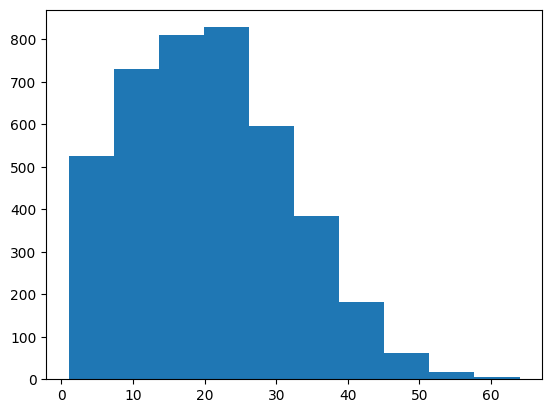

In [31]:
plt.hist(data_poisson['exam_score_int'])

In [32]:
formula_poisson_a = '''exam_score_int ~ productivity_score 
                                      + focus_index 
                                      + burnout_level 
                                      + gaming
                                      + C(academic_level, Treatment(reference=1))'''

In [33]:
formula_poisson_b = '''exam_score_int ~ study_hours 
                                      + sleep_hours
                                      + mental_health_score
                                      + burnout_level
                                      + gaming
                                      + C(academic_level, Treatment(reference=1))'''

In [34]:
poisson = smf.poisson(formula_poisson_a, data = data_poisson).fit(cov_type='HC1')
print(poisson.summary())

Optimization terminated successfully.
         Current function value: 3.234766
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 4140
Model:                        Poisson   Df Residuals:                     4133
Method:                           MLE   Df Model:                            6
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.4248
Time:                        20:59:48   Log-Likelihood:                -13392.
converged:                       True   LL-Null:                       -23282.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                           

In [35]:
poisson = smf.poisson(formula_poisson_b, data = data_poisson).fit(cov_type='HC1')
print(poisson.summary())

Optimization terminated successfully.
         Current function value: 3.538801
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 4140
Model:                        Poisson   Df Residuals:                     4132
Method:                           MLE   Df Model:                            7
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.3707
Time:                        20:59:48   Log-Likelihood:                -14651.
converged:                       True   LL-Null:                       -23282.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                           

In [36]:
formula_poisson_real = '''exam_score_int ~ productivity_score + study_hours + sleep_hours + mental_health_score + burnout_level
                                      + gaming + social_media_hours + C(academic_level, Treatment(reference=1))'''

poisson_real = smf.poisson(formula_poisson_real, data = data_poisson).fit(cov_type='HC1')
print(poisson_real.summary())

Optimization terminated successfully.
         Current function value: 3.282928
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 4140
Model:                        Poisson   Df Residuals:                     4130
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.4162
Time:                        20:59:48   Log-Likelihood:                -13591.
converged:                       True   LL-Null:                       -23282.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                           

En el modelo Poisson los coeficientes se interpretan como cambios en el logaritmo de la tasa esperada de la nota, por lo que se reportan los efectos marginales para faciltiar la interpretación.

Se hicieron 3 iteraciones de prueba para poder armar el modelo final (el cual se usará en las sig. preguntas):

**Modelo A:** Se contó con la misma especificación que se usaron en las preguntas anteriores, donde se rescataron la mayoría de las variables pero `gaming` resultó no significativa (p = 0.758), lo que resultó llamativo, aunque no se decidió eliminarla de inmediato se prestó atención a su efecto en las demás iteraciones.

**Modelo B:** Se incluyeron variables antes descartadas como `study_hours`, `sleep_hours`, `mental_health_score`, variables que explicaban hábitos más concretos dejando afuera `prodctivity_score` como prueba, todas las variables agregadas resultaron significativas incluyendo la bianria `gaming` (p = 0.010): el Pseudo R² fue menor al delm Modelo A

**Modelo final:** Se hizo una combinación de ambas aproximaciones, incluyendo `prodctivity_score` y `social_media_hours`, esta última a modo de prueba. Esta especificación logró el mejor ajuste de entre las 3 iteraciones con un Pseudo R² de 0.4162, contando con todas sus variables significativas. El incluir `prodctivity_score` junto a las demás variables resultó complementaria.

La variable `academic_level` no fue significativa en ninguna iteración, lo que sugiere que el nivel educativo de un estudiante no explica la nota una vez controlado por los hábitos e indices de bienestar. 


### 7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

In [37]:
# Test de Overdispersion.
aux=((data_poisson['exam_score_int']-poisson_real.predict())**2-poisson_real.predict())/poisson_real.predict()
auxr=sm.OLS(aux,poisson_real.predict()).fit()
print(auxr.summary())

                                 OLS Regression Results                                
Dep. Variable:         exam_score_int   R-squared (uncentered):                   0.050
Model:                            OLS   Adj. R-squared (uncentered):              0.049
Method:                 Least Squares   F-statistic:                              216.4
Date:                Tue, 21 Apr 2026   Prob (F-statistic):                    8.62e-48
Time:                        20:59:48   Log-Likelihood:                         -9777.4
No. Observations:                4140   AIC:                                  1.956e+04
Df Residuals:                    4139   BIC:                                  1.956e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

El test de sobredispersión entrega un alpha estimado de 0.0254 (p < 0.000), positivo y estadísticamente significativo. Esto indica que la varianza de la variable dependiente `exam_score_int` excede a su media, violando el supuesto de equidispersión de Poisson. El valor óptimo de alpha para el modelo Binomial Negativa es por tanto 0.0254.

### 8. Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [38]:
bin_neg = smf.negativebinomial(formula_poisson_real, data = data_poisson).fit(cov_type='HC1')

print(bin_neg.summary())

Optimization terminated successfully.
         Current function value: 3.204511
         Iterations: 24
         Function evaluations: 42
         Gradient evaluations: 35
                     NegativeBinomial Regression Results                      
Dep. Variable:         exam_score_int   No. Observations:                 4140
Model:               NegativeBinomial   Df Residuals:                     4130
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.1613
Time:                        20:59:49   Log-Likelihood:                -13267.
converged:                       True   LL-Null:                       -15818.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [39]:
#Efectos Marginales
mfx_nb = bin_neg.get_margeff()
print(mfx_nb.summary())

  NegativeBinomial Marginal Effects  
Dep. Variable:         exam_score_int
Method:                          dydx
At:                           overall
                                                    dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
C(academic_level, Treatment(reference=1))[T.0]     0.0584      0.237      0.247      0.805      -0.406       0.523
C(academic_level, Treatment(reference=1))[T.2]    -0.0725      0.234     -0.310      0.757      -0.531       0.386
productivity_score                                 0.5389      0.019     28.458      0.000       0.502       0.576
study_hours                                        0.3856      0.127      3.041      0.002       0.137       0.634
sleep_hours                                        0.2944      0.097      3.022      0.003       0.103       0.485
mental_health_score                        

Se usó la misma especificación que se usó en el modelo Poisson, el alpha estimado resultó de 0.038 con un valor-p < 0.001.

En cuanto a las variables `productivity_score`, `study_hours`, `sleep_hours`, `mental_health_score`, 
`burnout_level` y `social_media_hours` se mantienen con sus significancias al 5%, con efectos marginales de +0.539, 0.386, +0.294, +0.458, -0.187 y -0.530 respectivamente, se destaca el efecto de `productivity_score`, el cual es el predictor con mayor efecto positivo, mientras que `social_media_hours` es la que tiene el mayor efecto negativo marginal.

La variable `gaming` rsulto borderline con un valor-p de 0.054, perdiendo su significancia respecto al modelo Poiosson. Lo que sugiere que su efecto es sensible al supuesto ditribucional.

`academic_level` no resultó significativa en ninguna categoría, lo que es consistente con lo modelos anteriores.

### 9. Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [40]:
stargazer_conteo = Stargazer([poisson_real, bin_neg])
stargazer_conteo.title('Comparación de Modelos: Poisson vs Binomial Negativo')
stargazer_conteo.add_custom_notes([
    "Errores estándar robustos HC1 entre paréntesis.",
    'Alpha en BN confirma sobredispersión.'])

HTML(stargazer_conteo.render_html())

In [41]:
# Efectos Marginales Comparados
ef_poisson = poisson_real.get_margeff()
ef_nb = bin_neg.get_margeff()

efectos_comparados = pd.DataFrame({'Poisson (dy/dx)': ef_poisson.margeff, 'Binomial Negativo (dy/dx)': ef_nb.margeff})

pvals_comparados = pd.DataFrame({'Poisson (p-value)': ef_poisson.pvalues, 'Binomial Negativo (p-value)': ef_nb.pvalues})

print('Efectos Marginales Comparados:')
print(efectos_comparados.round(4).to_string())
print('\nP-values Comparados:')
print(pvals_comparados.round(4).to_string())

print('Ajuste de los modelos')
print(f"Poisson: Log-likelihood = {poisson_real.llf:.2f}, AIC = {poisson_real.aic:.2f}")
print(f"Binomial Negativo: Log-likelihood = {bin_neg.llf:.2f}, AIC = {bin_neg.aic:.2f}")

Efectos Marginales Comparados:
   Poisson (dy/dx)  Binomial Negativo (dy/dx)
0           0.0149                     0.0584
1          -0.0246                    -0.0725
2           0.5039                     0.5389
3           0.3229                     0.3856
4           0.2677                     0.2944
5           0.4331                     0.4577
6          -0.1689                    -0.1872
7          -0.6127                    -0.5848
8          -0.4646                    -0.5298

P-values Comparados:
   Poisson (p-value)  Binomial Negativo (p-value)
0             0.9468                       0.8053
1             0.9107                       0.7566
2             0.0000                       0.0000
3             0.0088                       0.0024
4             0.0032                       0.0025
5             0.0000                       0.0000
6             0.0000                       0.0000
7             0.0312                       0.0544
8             0.0000                 

**Diferencias entre modelos:**

El supuesto de equidispersión de Poisson (varianza = media) fue rechazado en la pregunta 7 (alpha = 0.025, p < 0.001). La Binomial Negaitva relaja dicho supuesto, haciendo una estimación del alpha conjuntamente, dando un alpha = 0.038 y valor-p < 0.001, lo que confirma la sobredispersión en `exam_score_int`. Si hablamos de ajuste, la Binomial Negativa presenta un AIC menor (26.555 vs 27.202).

**Variables robustas a la especificación:**

Se mantienen significativas en ambos modelos: `study_hours`,`sleep_hours`, `mental_health_score`, `burnout_level`, y `social_media_hours`. Adicionalmente sus efectos marginales son muy similares entre modelos.

**Variables no robustas:**

`gaming` es significativa en Poisson (p = 0.031) pero en Binomial Negativa pierde significancia llegando a borderline (p = 0.054). Al corregir la sobredispersión, los errores estándar aumentan y esta variable pierde significancia. Esto sugiere que su efecto era marginal y sensible al supuesto distribucional.

`academic_level` no es significativa en ninguno de los dos modelos, consistente con lo observado en los modelos de probabilidad.

**Modelo más adecuado:**

Dado que el supuesto de equidispersión de Poisson fue rechazado, la Binomial Negativa es el modelo adecuado para el análisis. Respecto a ambos modelos las concluciones no cambian y las mismas variables explican la nota, pero siendo la Binomial Ngeativa quien lo hace con mayor rigor estadistico.